In [6]:
%load_ext autoreload
%autoreload 2

import parse_data

parse_data.remove_commas_recursively("/Users/cameronliu/Desktop/Research/Datasets/sd-0.0025-exp-reformatted")

global_sd = 0.01



#tskit = True if global_sd == 0.0025 else False




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# Cell to calculate all the information to parse the information from the file 
# Need to develop a system to create a new file that's easier and faster to read the data from

import matplotlib.pyplot as plt
import numpy as np    
from scipy import stats
import statistics
import math

# This is my own .py file, with methods that I have created myself.
import parse_data

pop_size = 2000
burnin = 4*pop_size

# Set global theme settings for plotting
plt.rcParams.update({
    'font.size': 20,          # Set font size
    'lines.linewidth': 3,     # Set default line thickness
    'axes.titlesize': 20,     # Title font size
    'axes.labelsize': 18,     # Axis label font size
    'xtick.labelsize': 14,    # X-tick label font size
    'ytick.labelsize': 14,    # Y-tick label font size
    'grid.color': 'gray',     # Grid color
    'grid.linestyle': '--',   # Grid line style
    'grid.linewidth': 0.5,    # Grid line width
    'legend.fontsize': 16     # Legend font size
})

uds = [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.2, 0.35, 0.5, 0.75, 1, 1.25, 1.5, 2, 4, 6, 8]
wanted = [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.2, 0.35, 0.5, 0.75, 1, 1.25, 1.5, 2, 4, 6, 8]
uds.sort(); wanted.sort()

# These are important to remember
# parse_exp([uds], sd, BURNIN, COMMA)
data, timesteps = parse_data.parse_normal_from_exp(wanted, global_sd, True)
sliced_data, sliced_timesteps = parse_data.slice_data(data, timesteps, burnin)

# sliced_data's format = (sd, (ud, f. sel. deaths))


---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 0.01, UD = 0.01
---------------------------------------------------------

---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 0.01, UD = 0.02
---------------------------------------------------------

---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 0.01, UD = 0.03
---------------------------------------------------------

---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 0.01, UD = 0.05
---------------------------------------------------------

---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 0.01, UD = 0.075
---------------------------------------------------------

---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 

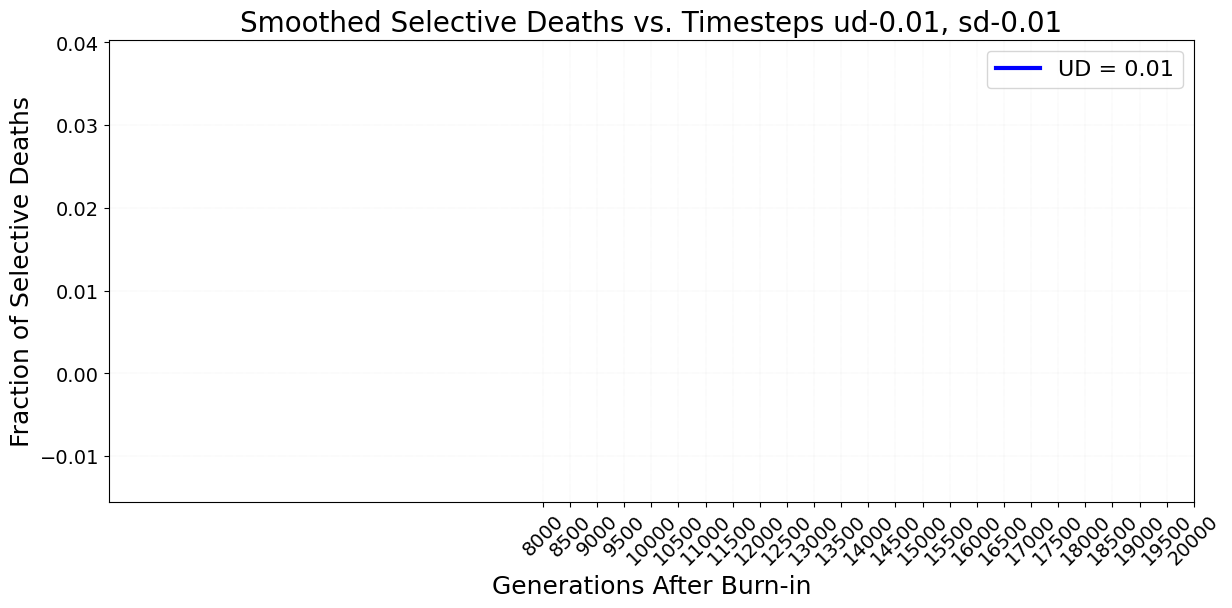

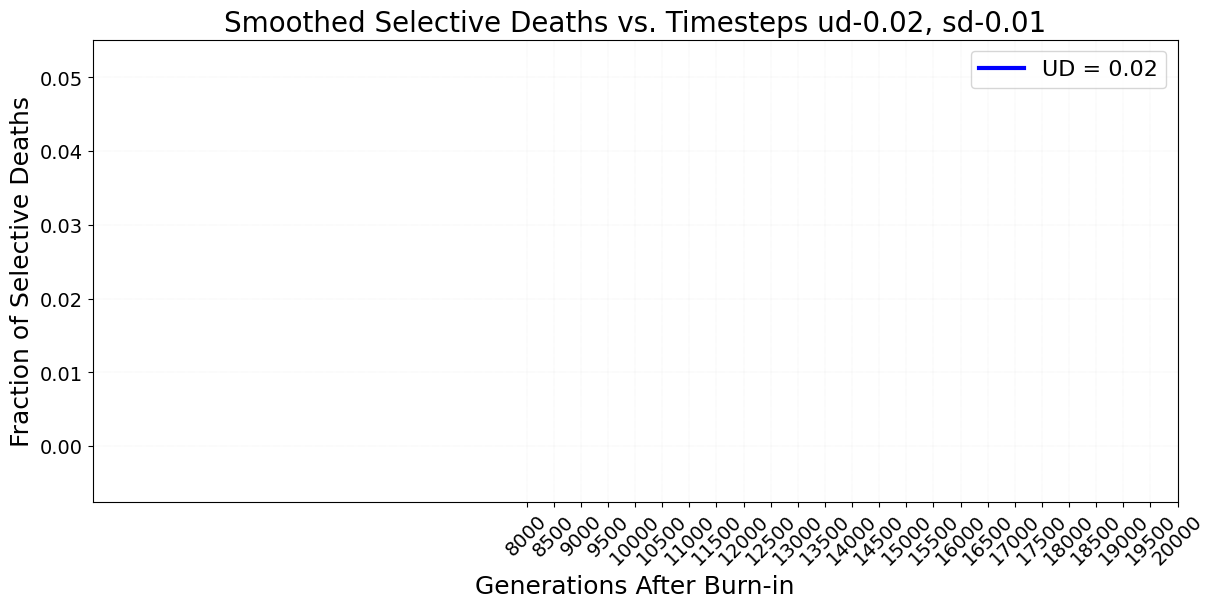

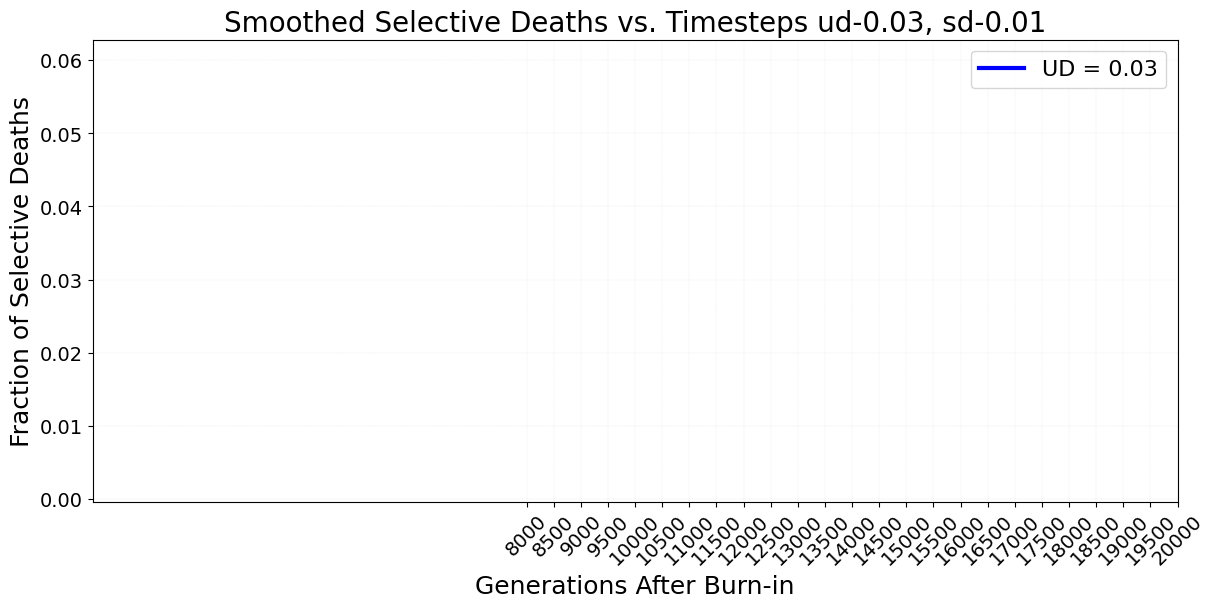

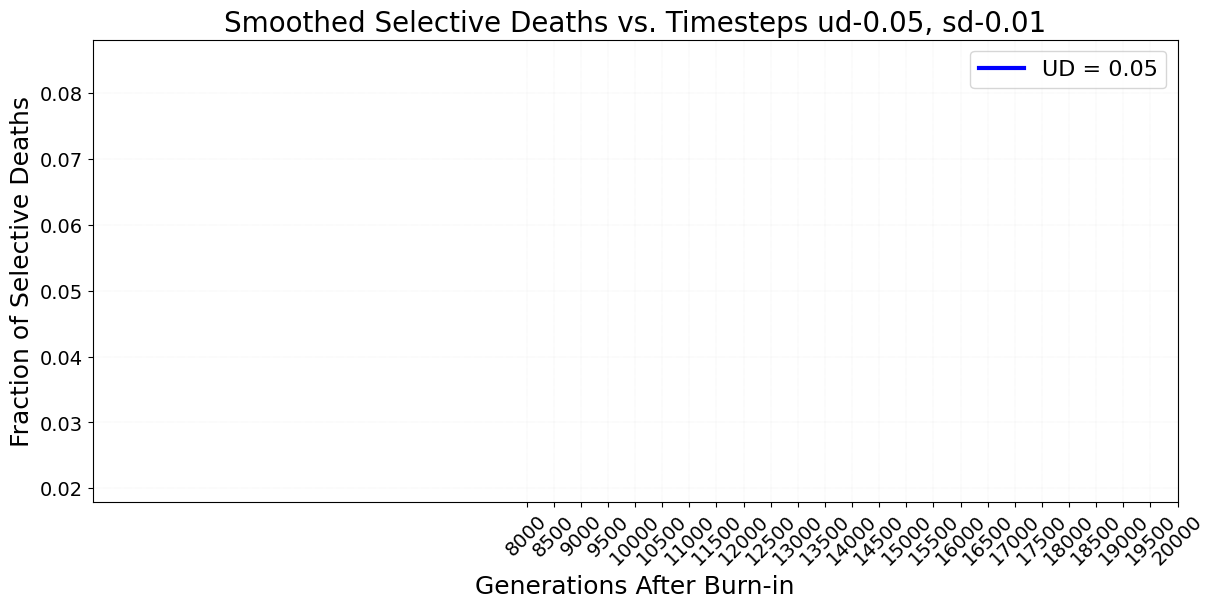

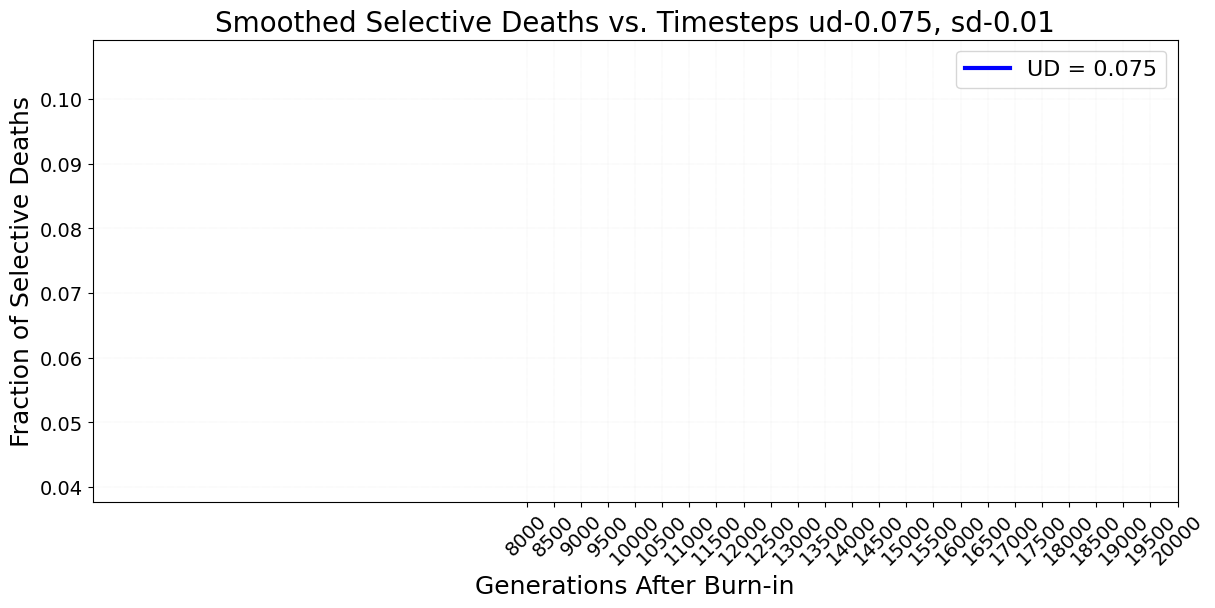

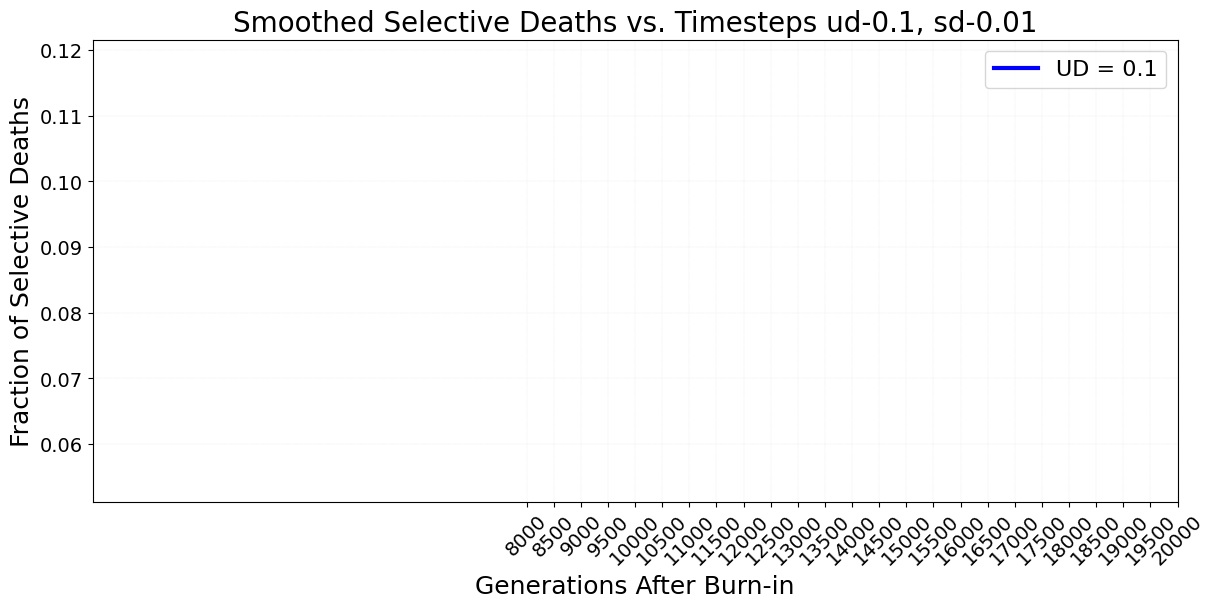

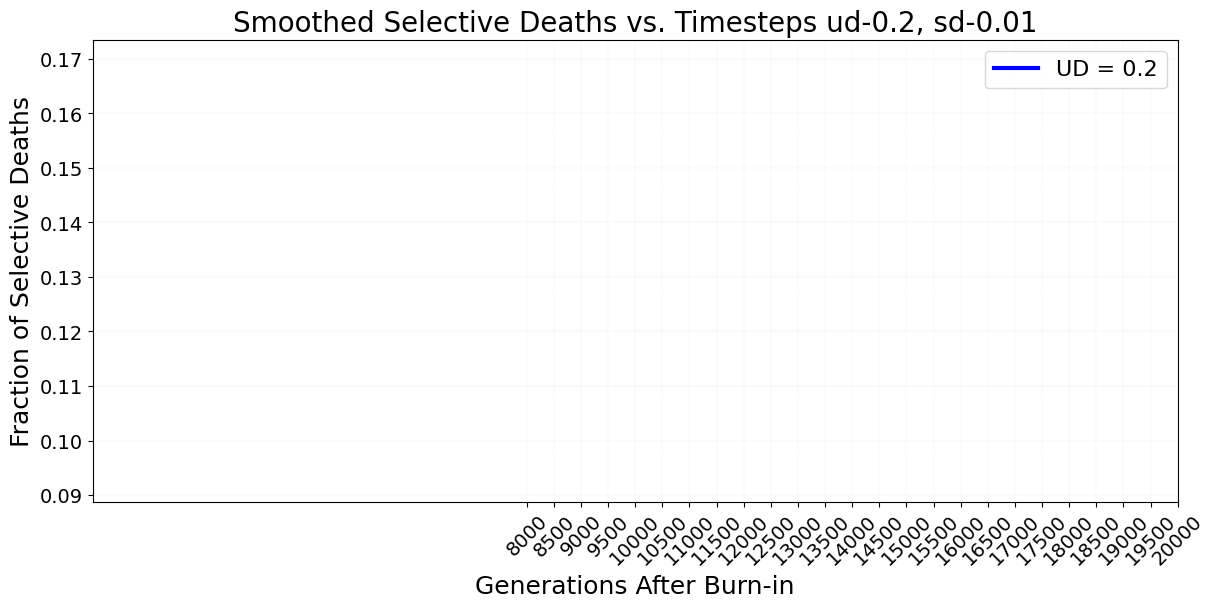

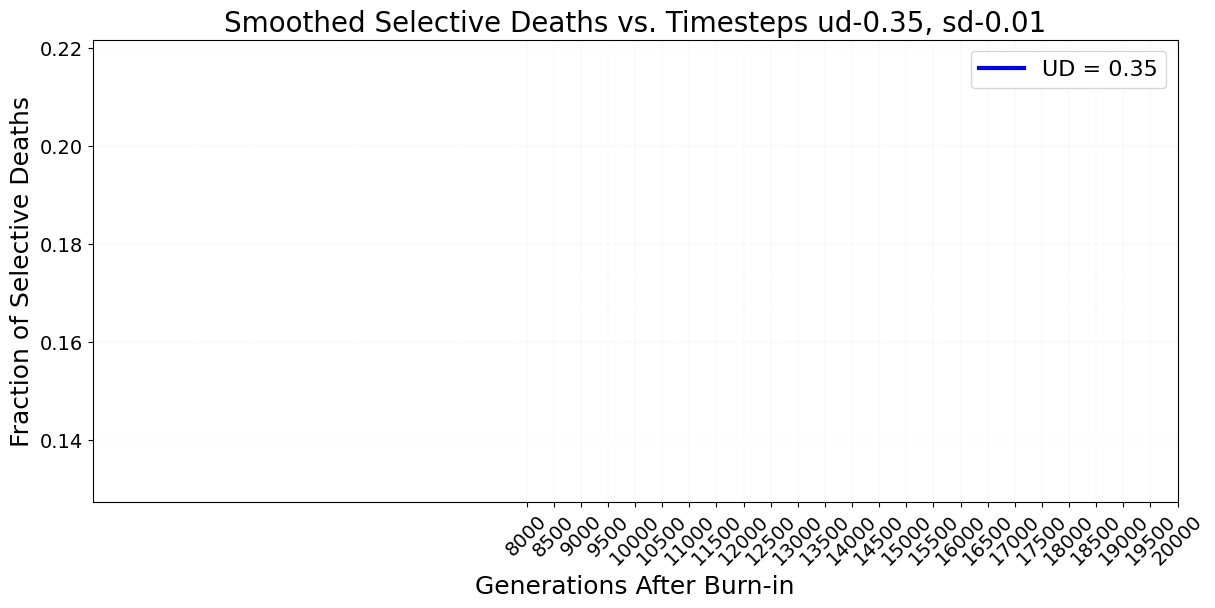

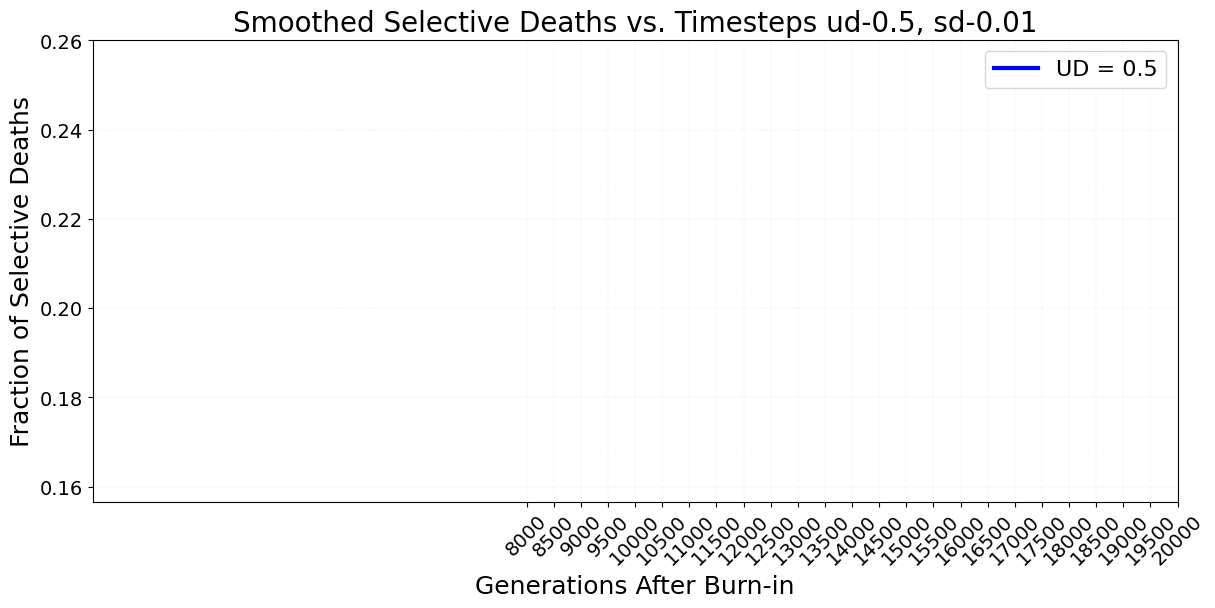

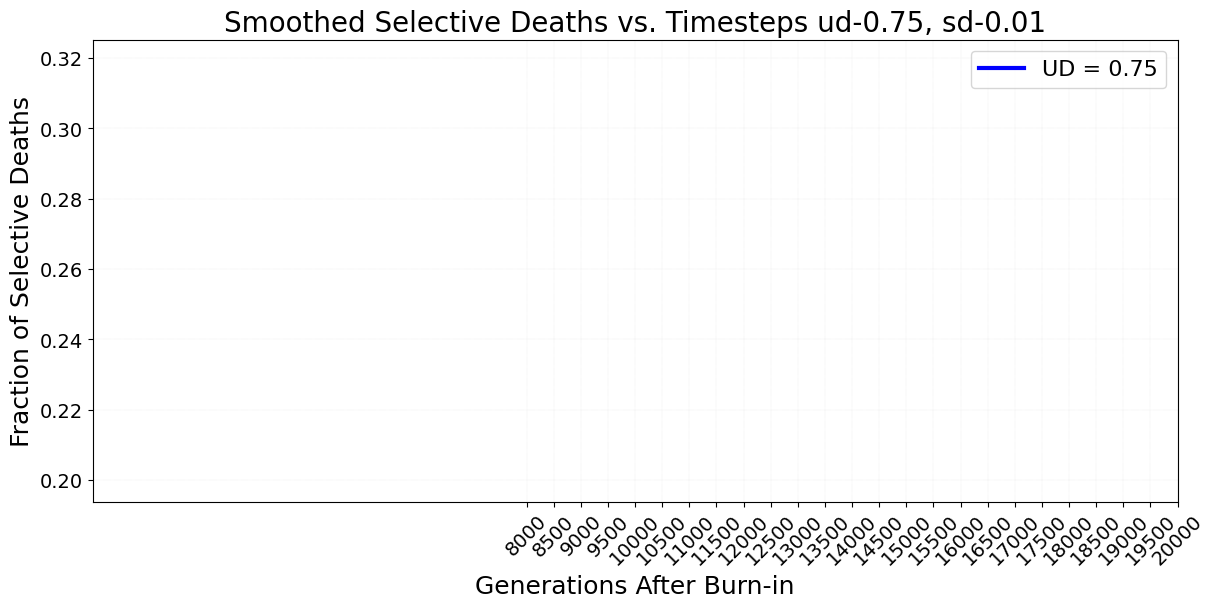

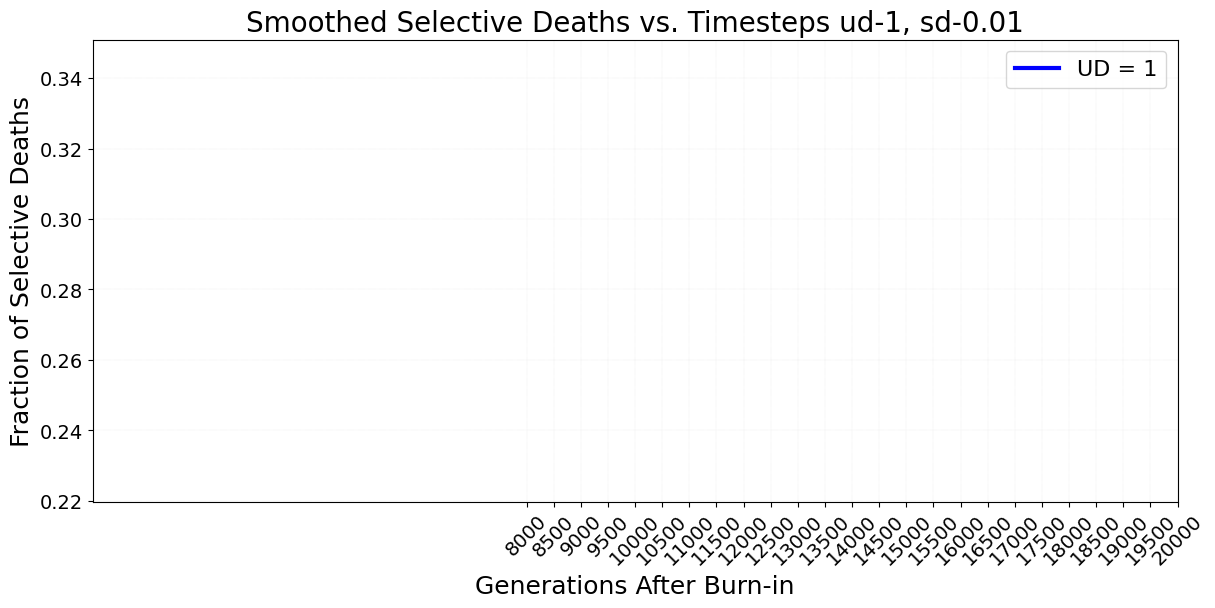

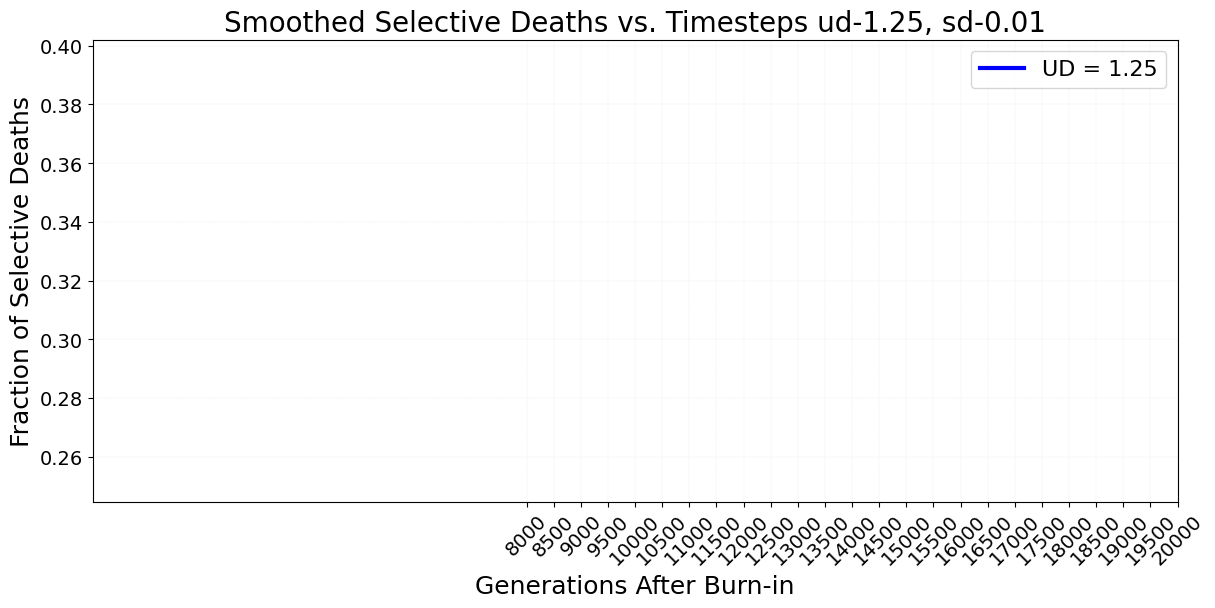

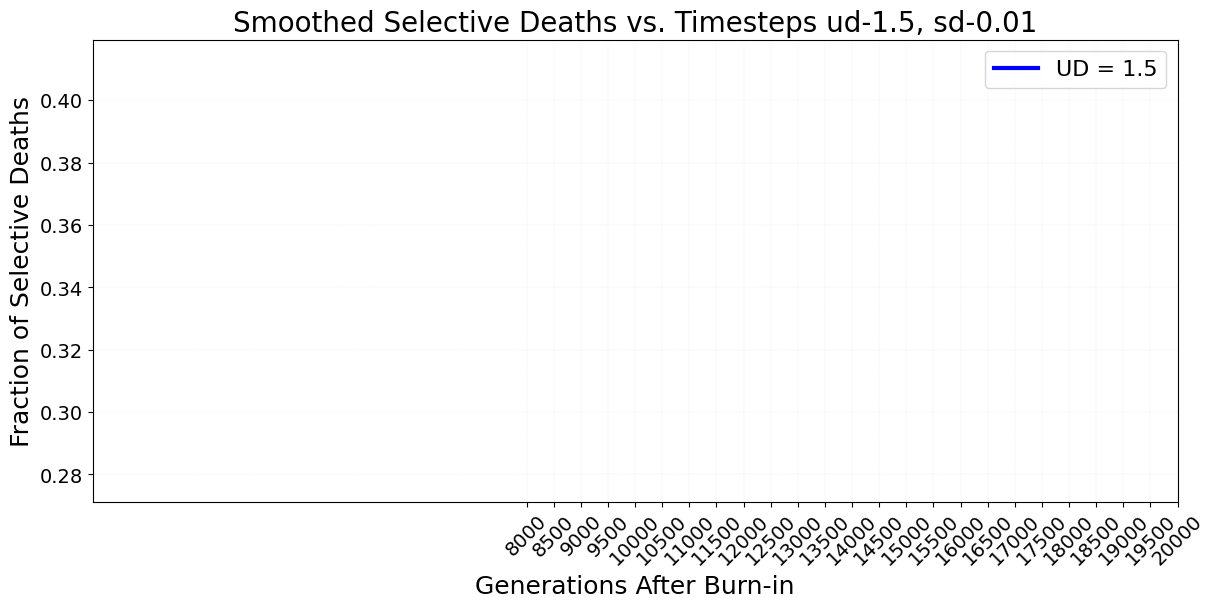

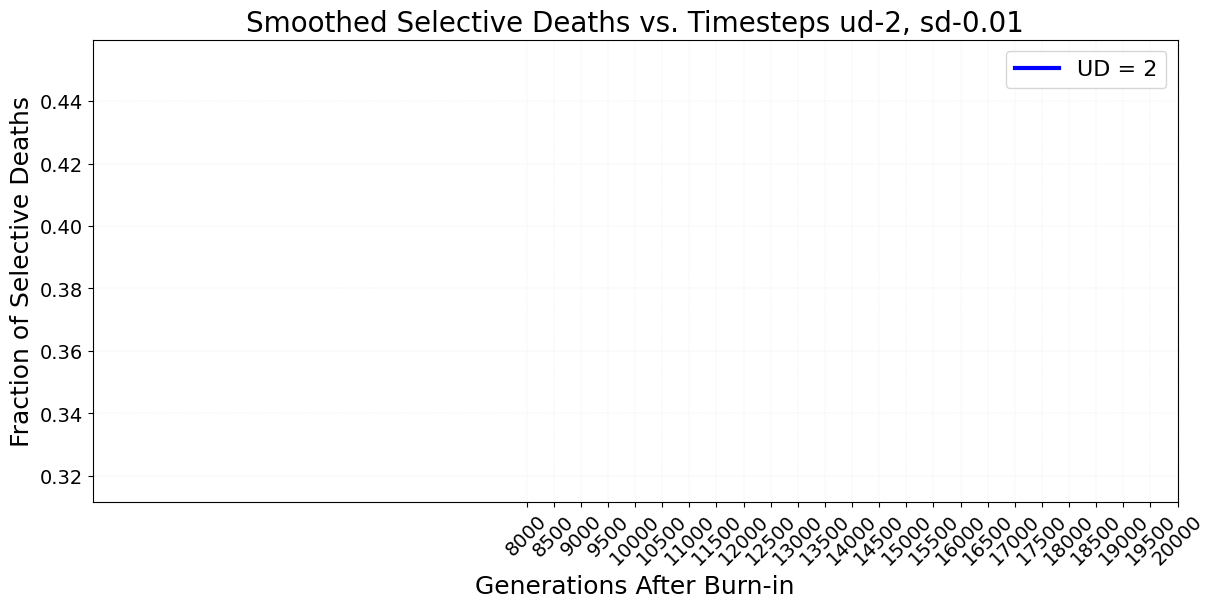

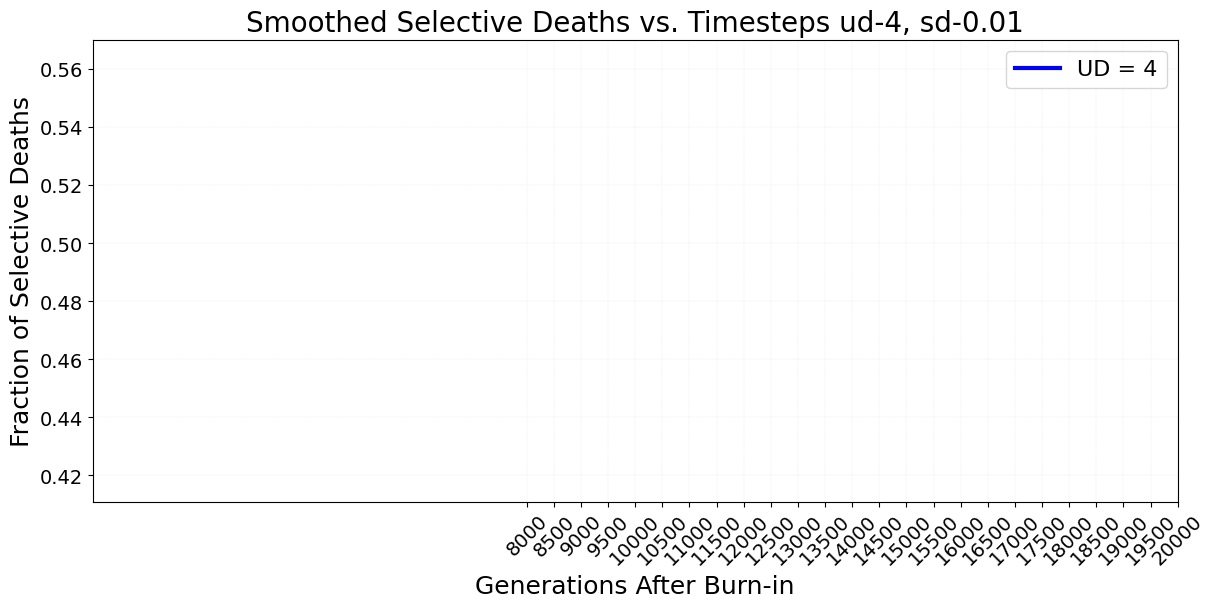

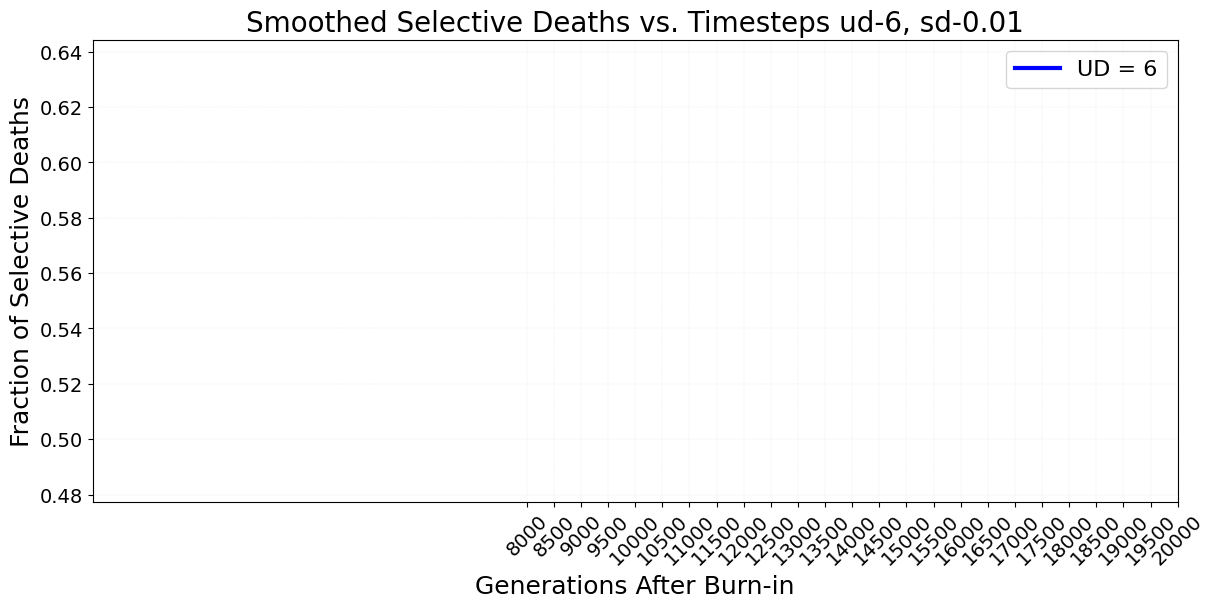

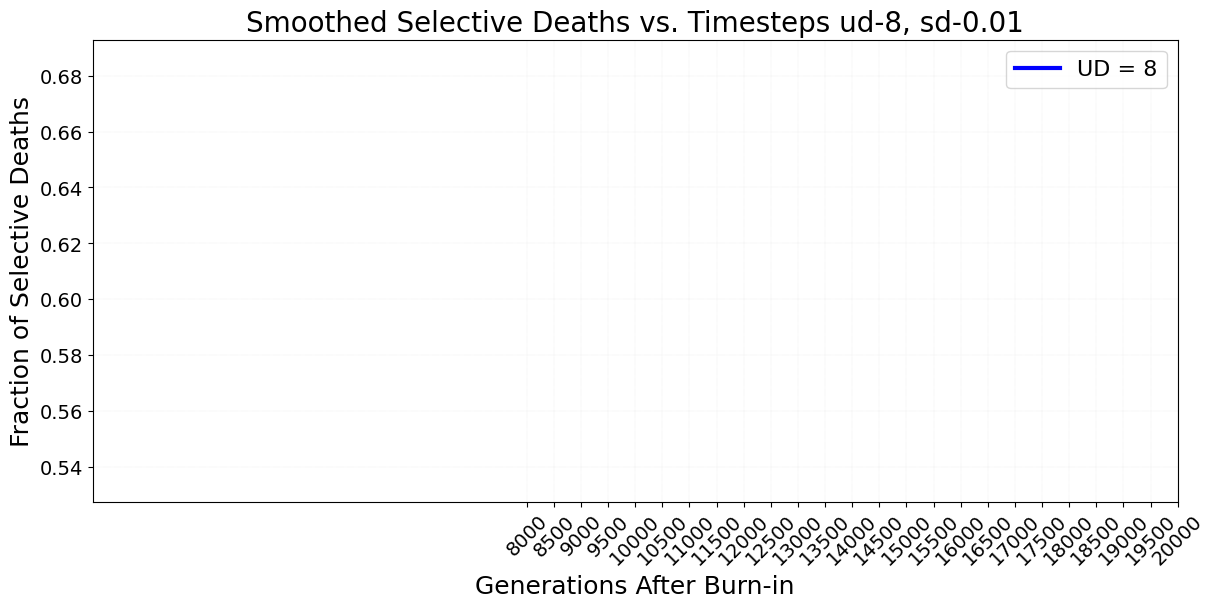

In [ ]:
# Timesteps vs. F. Sel. Deaths: No Burnin, Smoothed

window_size = 10
start = 8000  # Start X-axis here
end = len(sliced_timesteps)
tick_interval = 500  # Adjust tick interval to match smoothed data spacing

for sd, (ud, dataset) in sliced_data:
    if ud in wanted:
        used_data = parse_data.moving_average(dataset, window=window_size)
        #used_data = dataset

        # Align smoothed values with the center of the window
        offset = window_size // 2
        smoothed_timesteps = [int(timesteps[i + offset]) for i in range(len(used_data))]

        # Filter smoothed data/timesteps in desired range
        sliced_timesteps = []
        sliced_values = []
        for t, d in zip(smoothed_timesteps, used_data):
            if start <= t <= end:
                sliced_timesteps.append(t)
                sliced_values.append(d)

        # Set tick marks based on actual sliced timesteps
        tick_locs = list(range(start, max(sliced_timesteps) + 1, tick_interval))

        # Compute y-limits
        #y_min = 0
        #y_max = 1
        y_min = min(used_data) - 0.02
        y_max = max(used_data) + 0.02

        fig = plt.figure(figsize=(14, 6))
        fig.patch.set_facecolor('white')
        ax = fig.gca()
        ax.set_facecolor('white')

        ax.plot(sliced_timesteps, sliced_values, label=f"UD = {ud}", color='blue')
        ax.set_xlabel("Generations After Burn-in")
        ax.set_ylabel("Fraction of Selective Deaths")
        ax.set_title(f"Smoothed Selective Deaths vs. Timesteps ud-{ud}, {sd}")
        ax.grid(True, linestyle=':', color='lightgray', linewidth=0.3)
        ax.set_xticks(tick_locs)
        ax.set_ylim(y_min, y_max)
        plt.xticks(rotation=45)
        ax.legend()
        
        #plt.savefig(f"/Users/cameronliu/Desktop/Research/Selective Death Graphs/Exponential Graph/Exp No Burnin/Smoothed/{global_sd}/smoothed_sd-{sd[3:]}_ud-{ud}_vs_timesteps.png", dpi=300, bbox_inches='tight')
        plt.show()


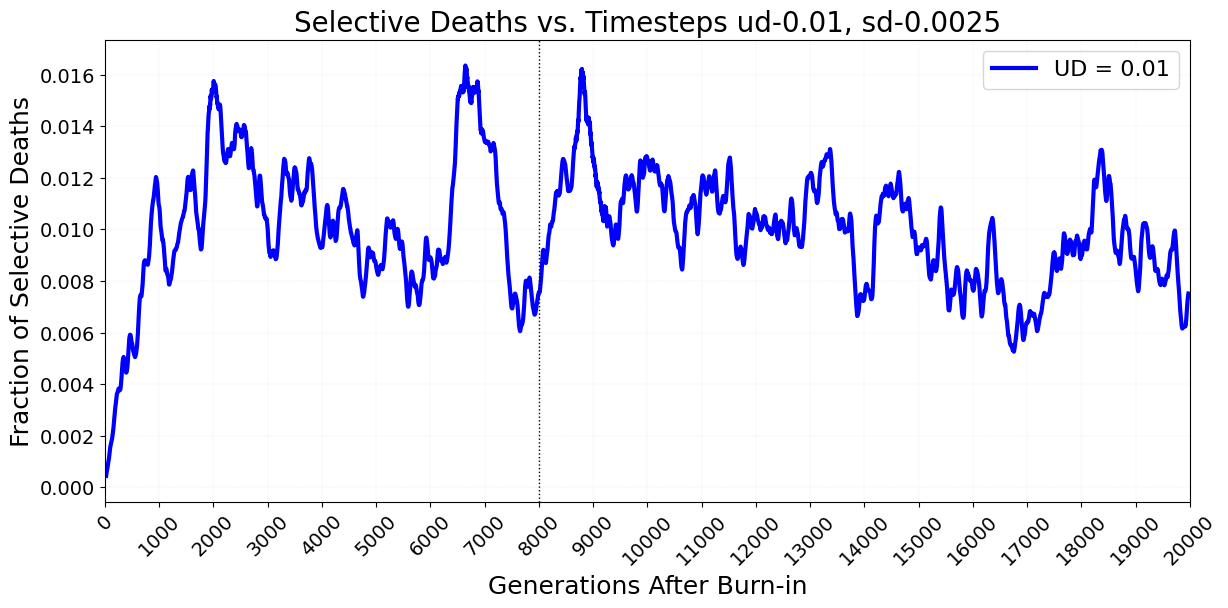

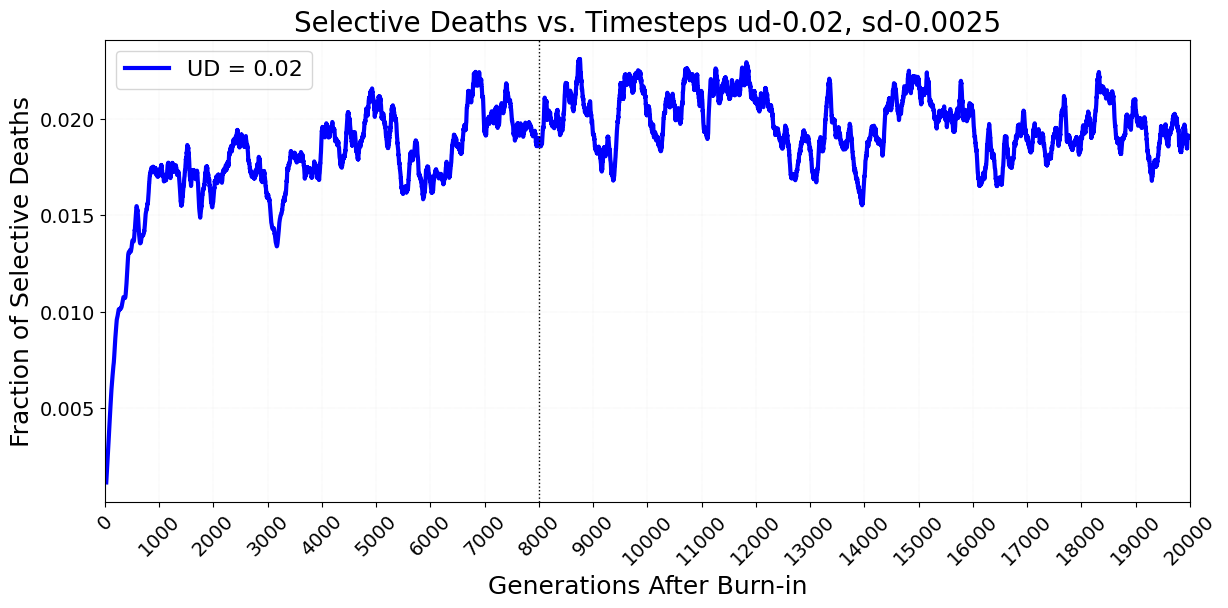

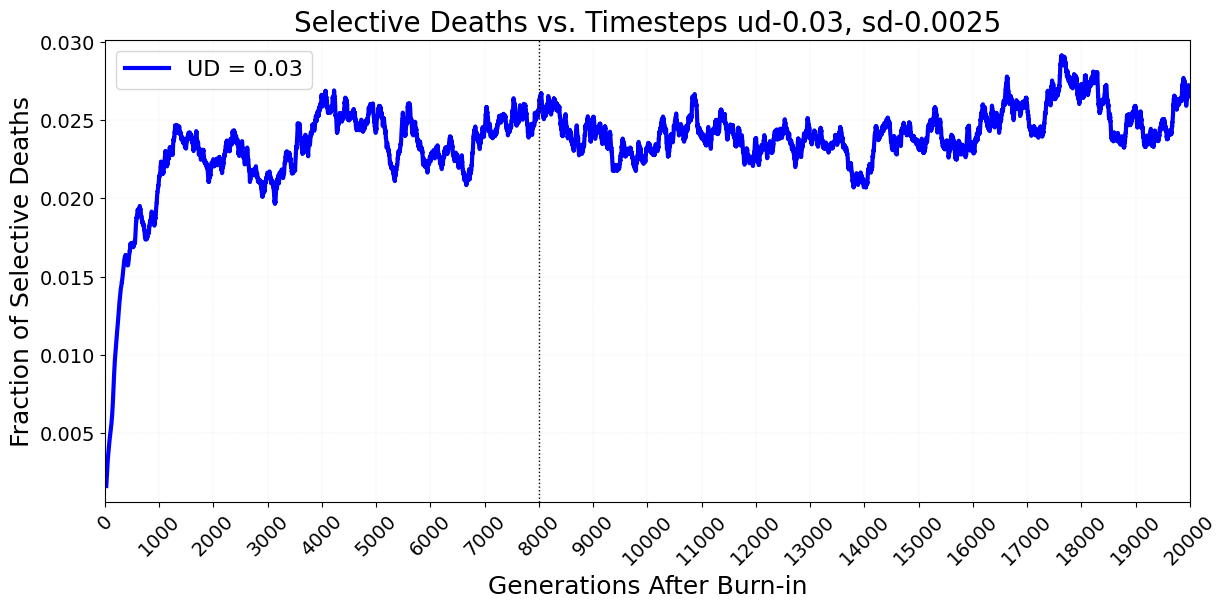

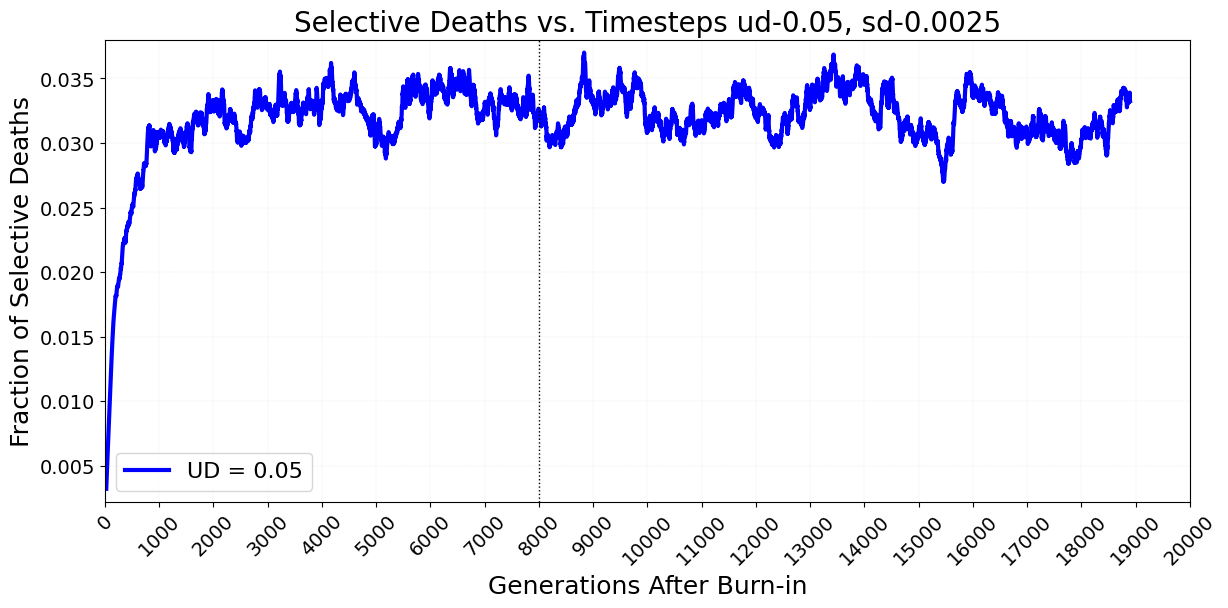

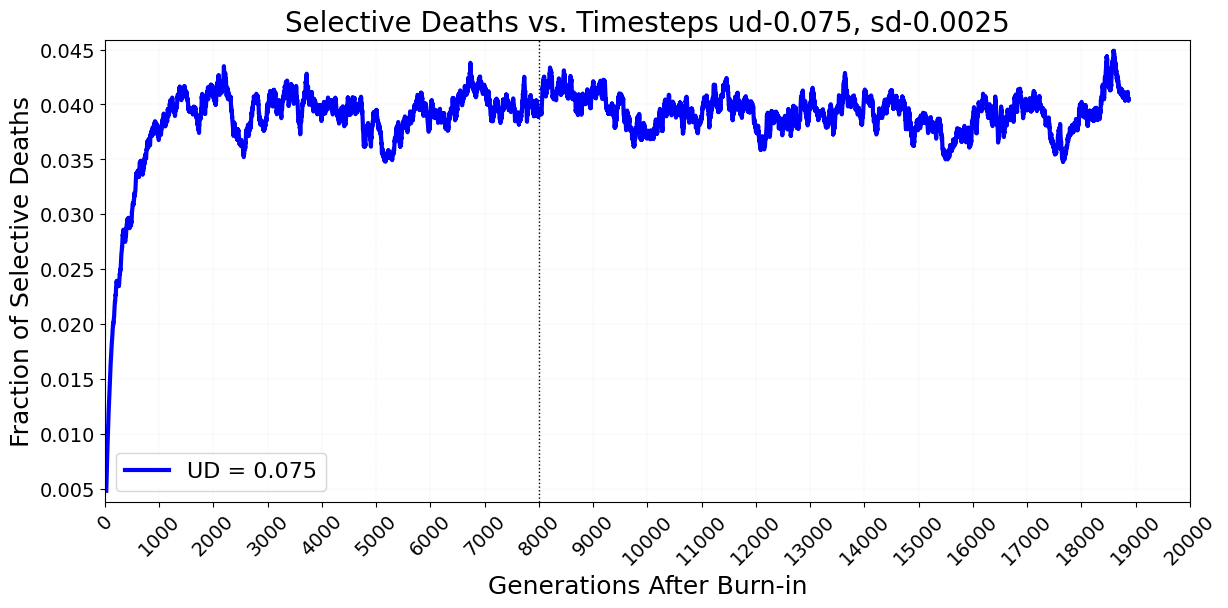

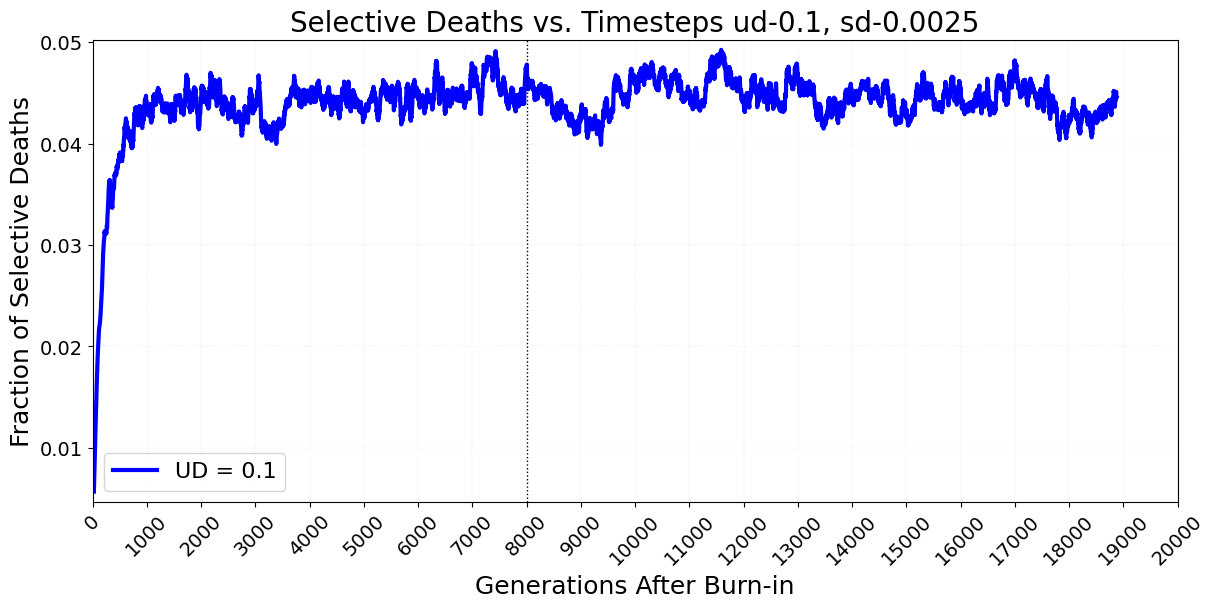

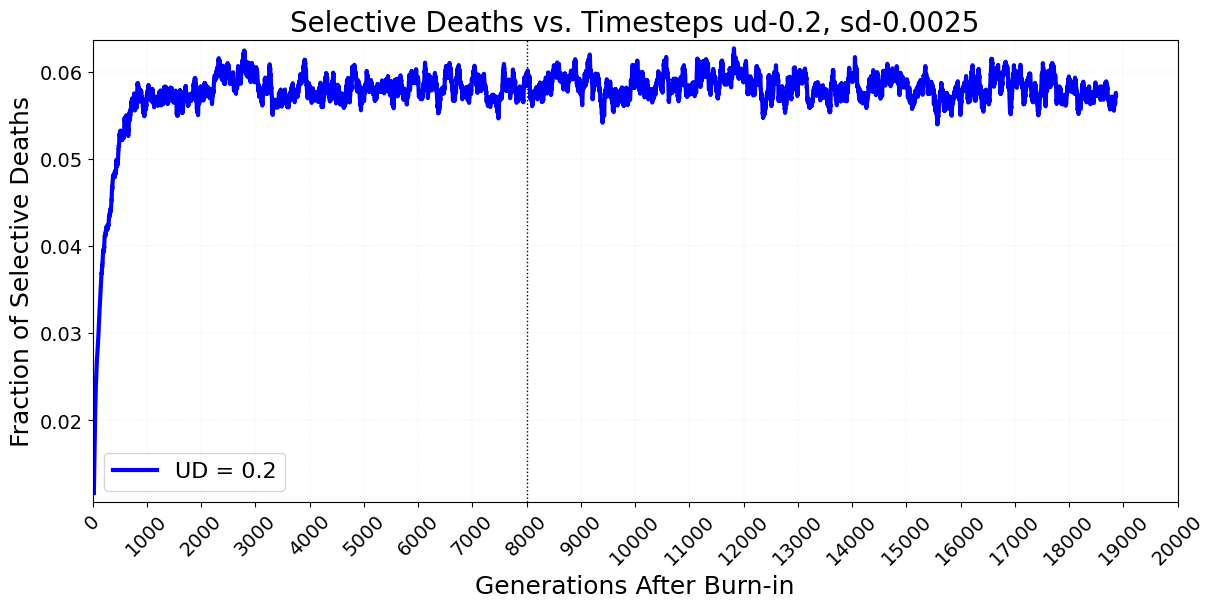

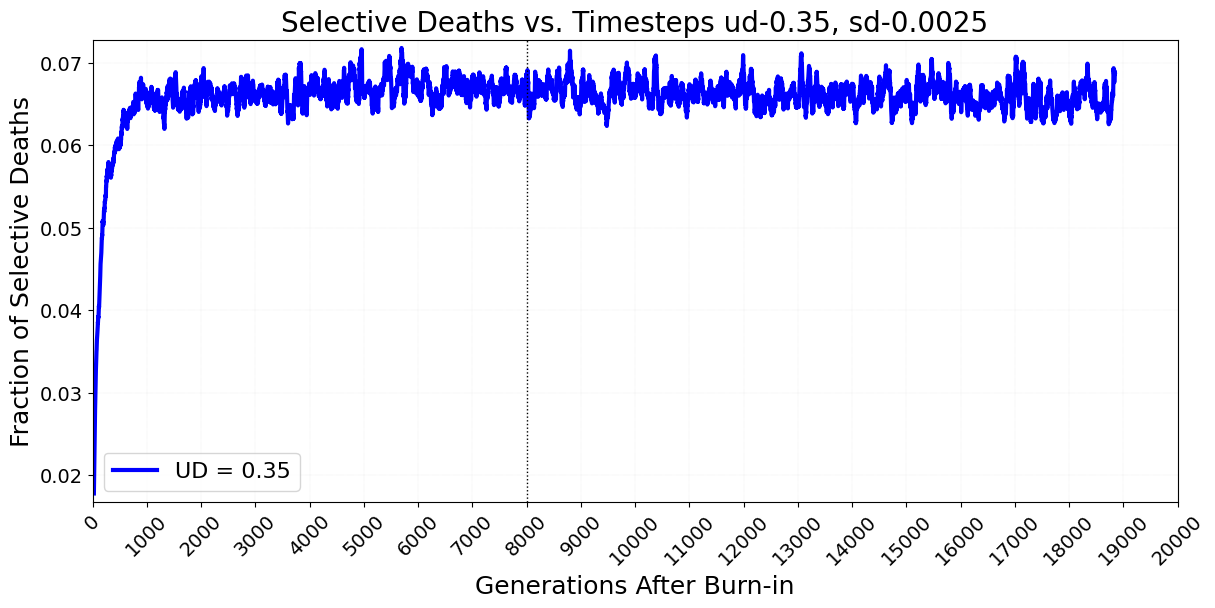

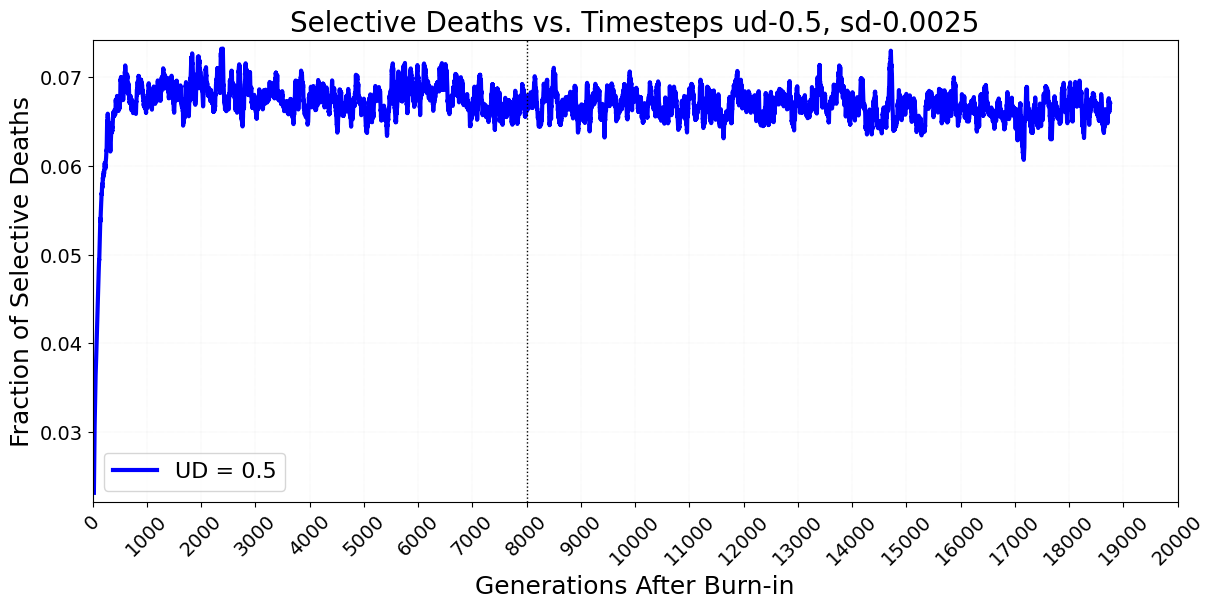

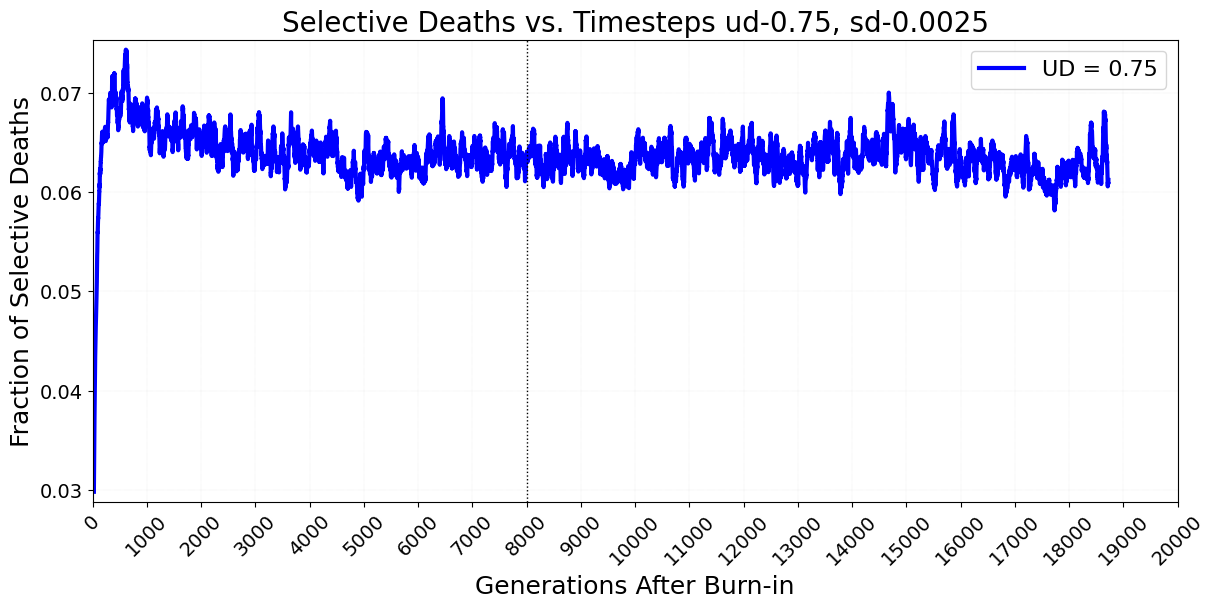

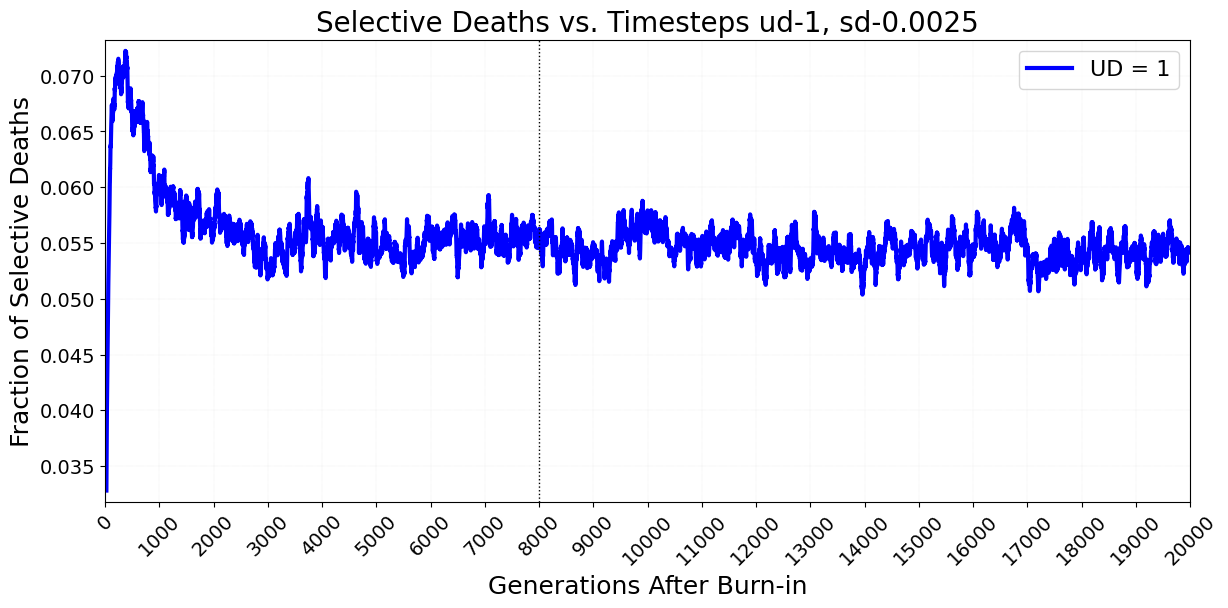

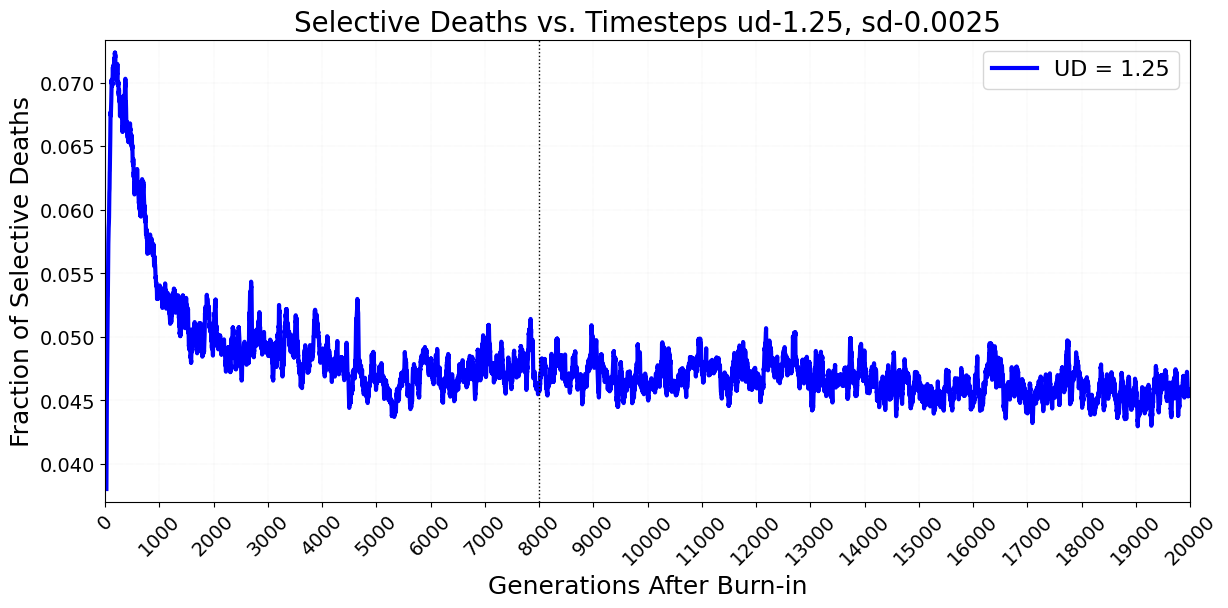

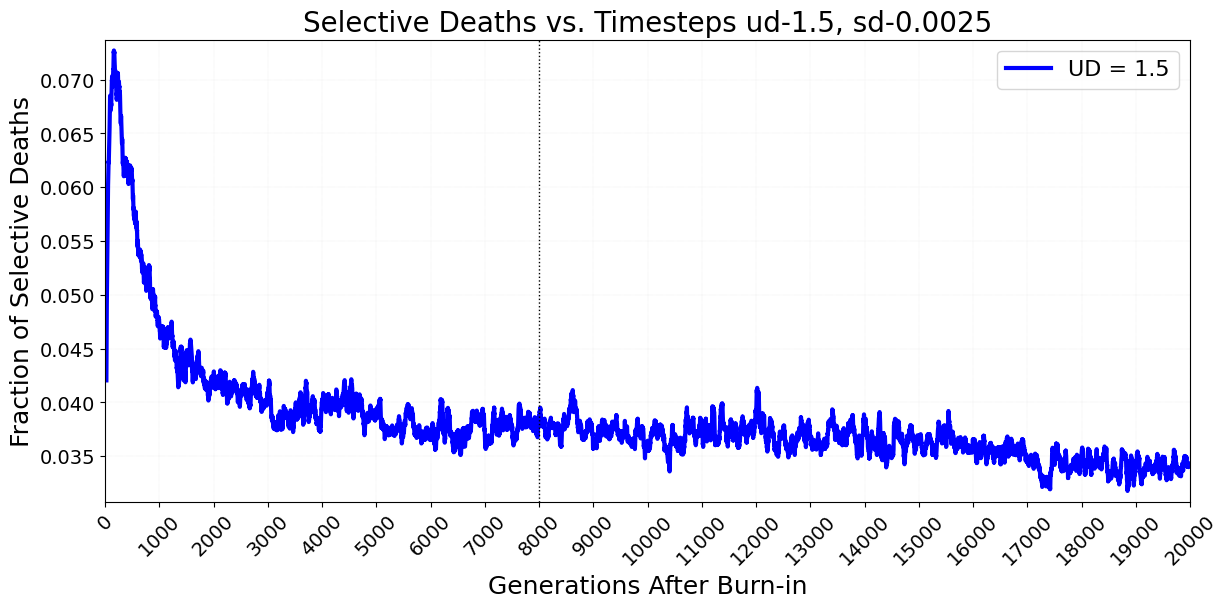

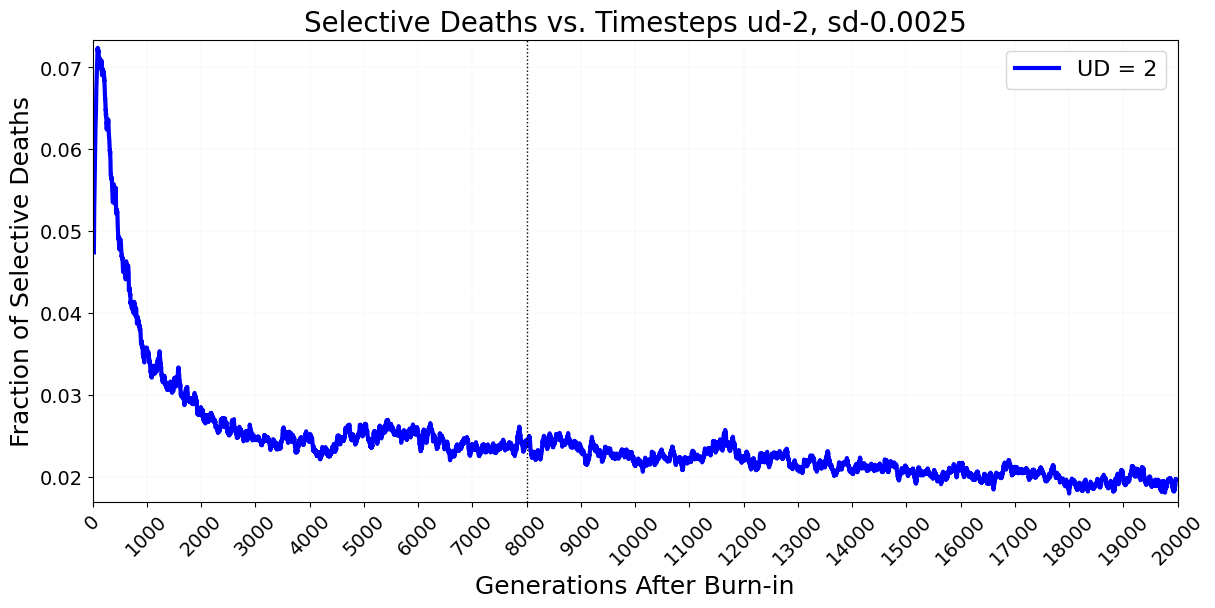

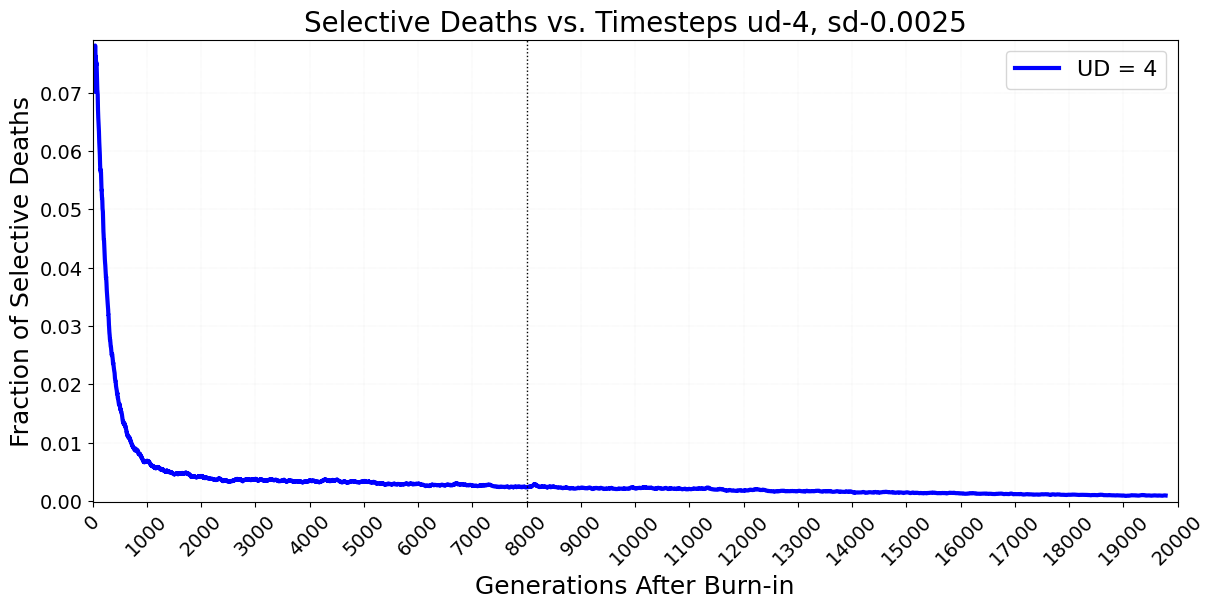

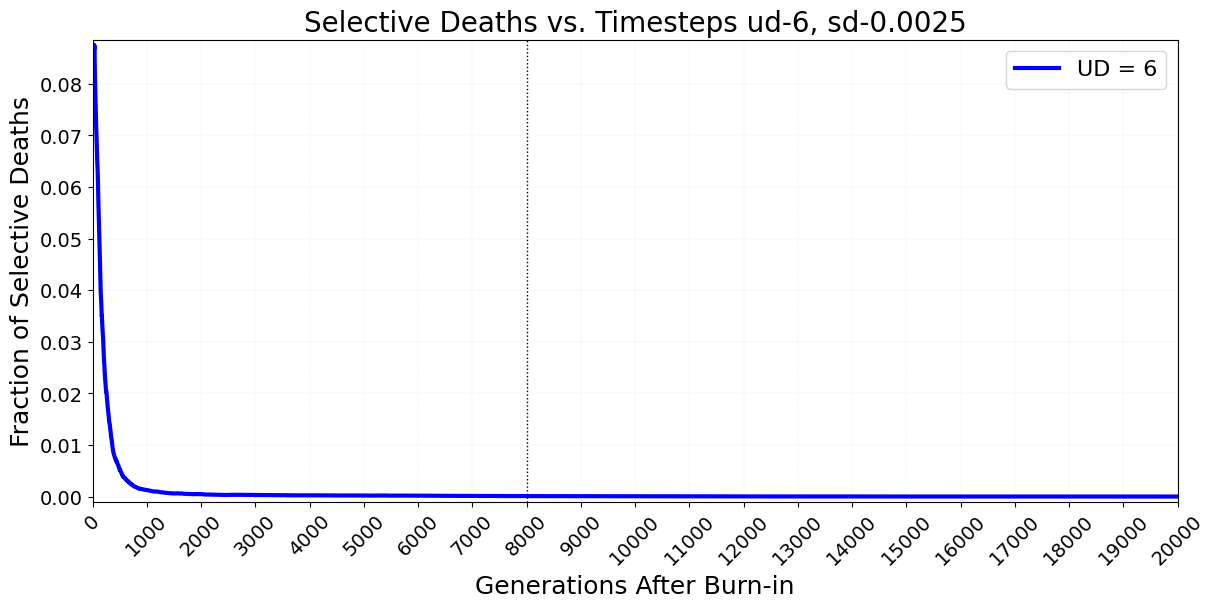

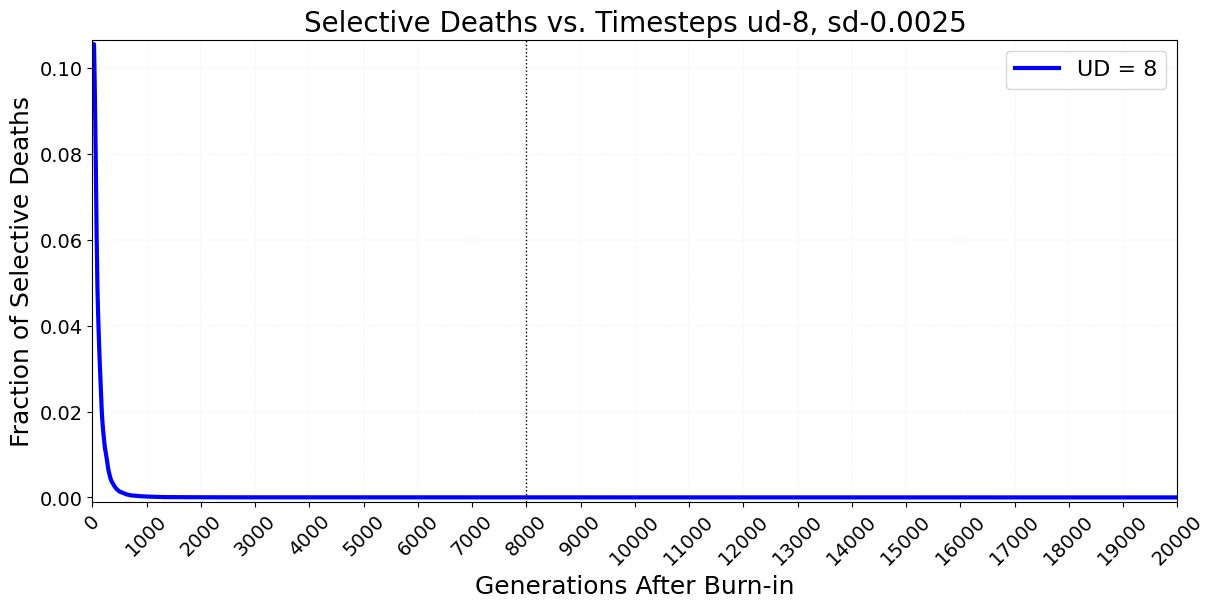

In [44]:
# Timesteps vs. F. Sel. Deaths: Burnin

tick_interval = 1000
x_start = 0
x_end = 20000
window_size = 50

for sd, (ud, dataset) in data:
    if ud in wanted:
        # Rebuild timesteps to ensure they start at 0
        timesteps = list(range(len(dataset)))

        # Smooth the dataset
        smoothed = parse_data.moving_average(dataset, window=window_size)

        # Align timesteps with smoothed data (centered window)
        offset = window_size // 2
        smoothed_timesteps = timesteps[offset : offset + len(smoothed)]

        # Set ticks: ensure 0 is included
        tick_locs = [0] + list(range(tick_interval, x_end + 1, tick_interval))

        # Compute y-limits from smoothed values
        y_min = min(smoothed) - 0.001
        y_max = max(smoothed) + 0.001

        fig = plt.figure(figsize=(14, 6))
        fig.patch.set_facecolor('white')
        ax = fig.gca()
        ax.set_facecolor('white')

        # Plot smoothed data
        ax.plot(smoothed_timesteps, smoothed, label=f"UD = {ud}", color='blue')

        # Add vertical line at burn-in end
        ax.axvline(x=8000, color='black', linestyle=':', linewidth=1)

        ax.set_xlabel("Generations After Burn-in")
        ax.set_ylabel("Fraction of Selective Deaths")
        ax.set_title(f"Selective Deaths vs. Timesteps ud-{ud}, {sd}")
        ax.grid(True, linestyle=':', color='lightgray', linewidth=0.3)

        # Set ticks and limits
        ax.set_xticks(tick_locs)
        ax.set_xlim(x_start, x_end)
        plt.xticks(rotation=45)

        ax.set_ylim(y_min, y_max)
        ax.legend()

        plt.savefig(f"/Users/cameronliu/Desktop/Research/Selective Death Graphs/Exponential Graph/Exp Burnin/Smoothed/{global_sd}/smoothed_sd-{sd[3:]}_ud-{ud}_vs_timesteps.png", dpi=300, bbox_inches='tight')
        plt.show()


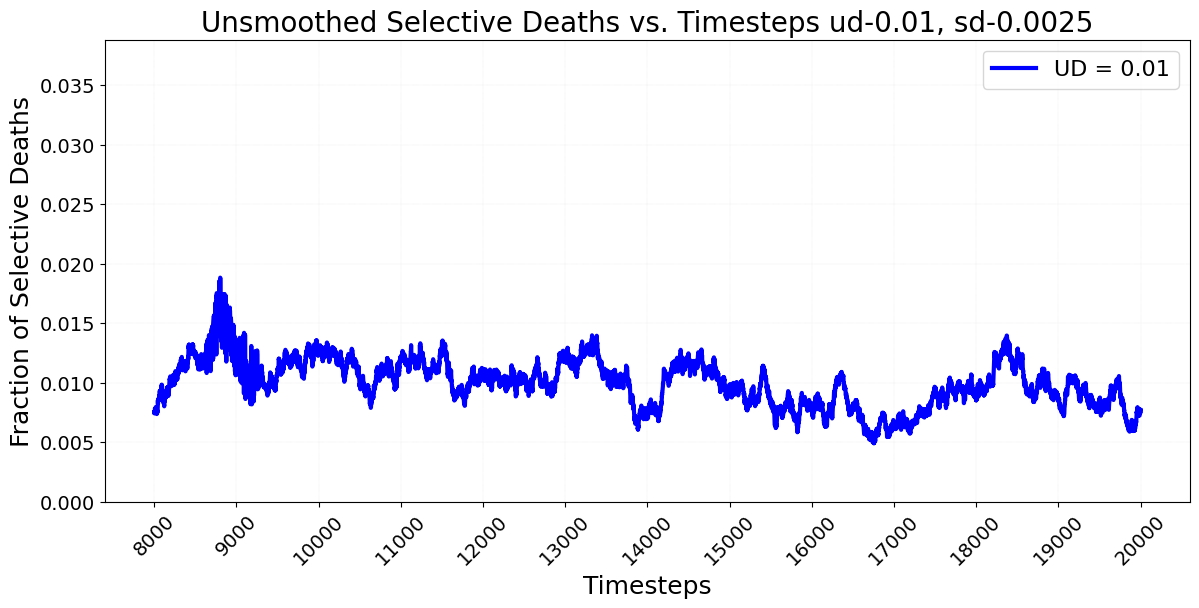

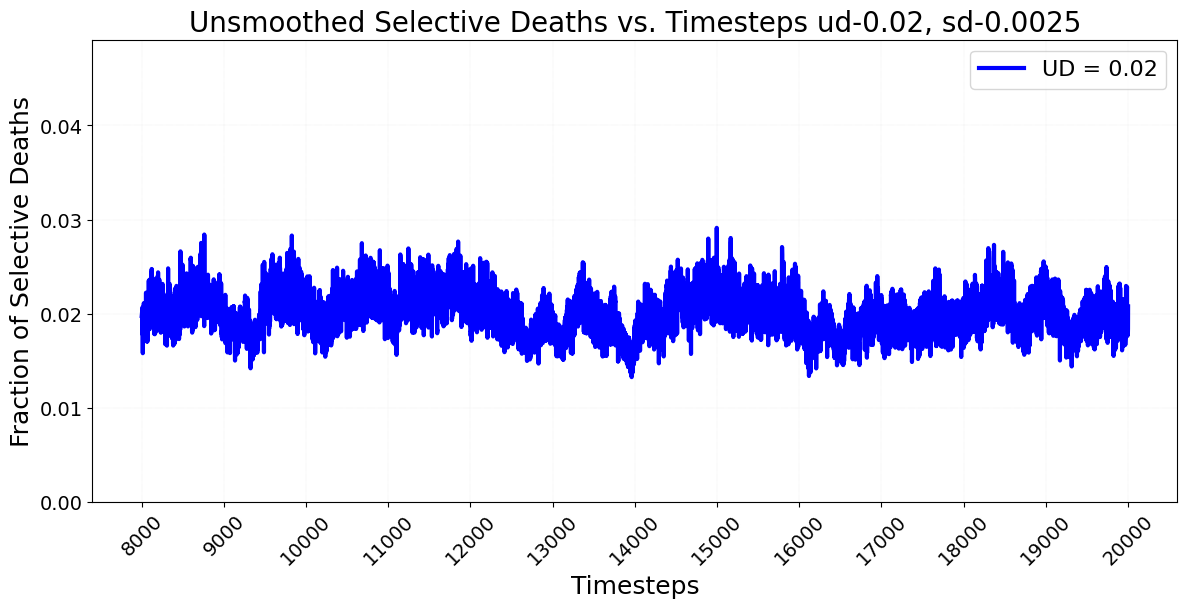

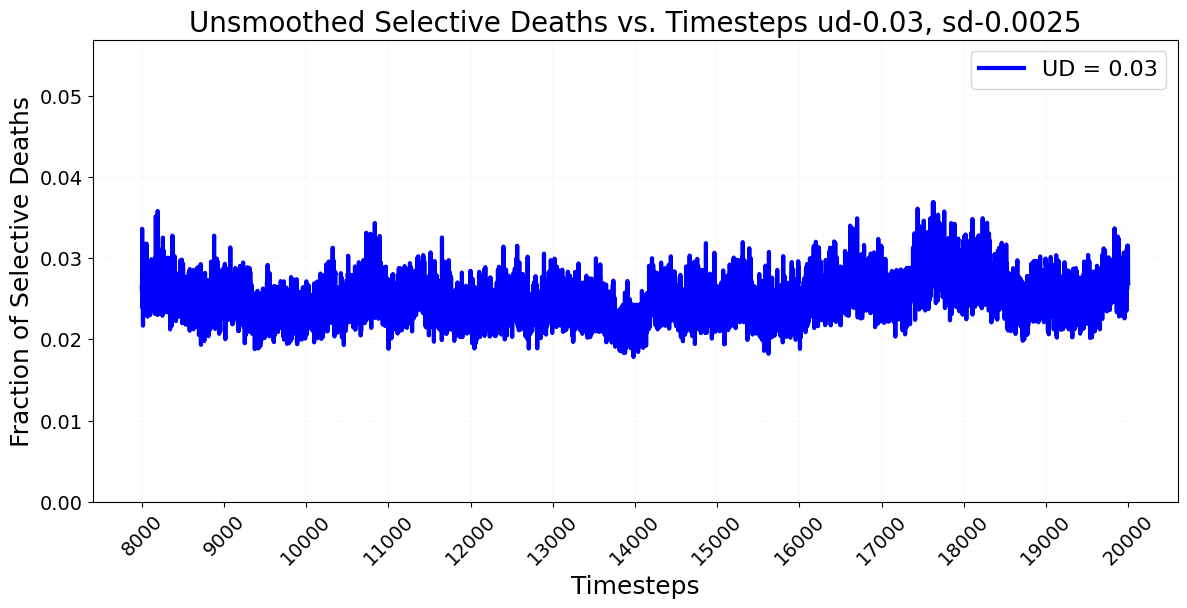

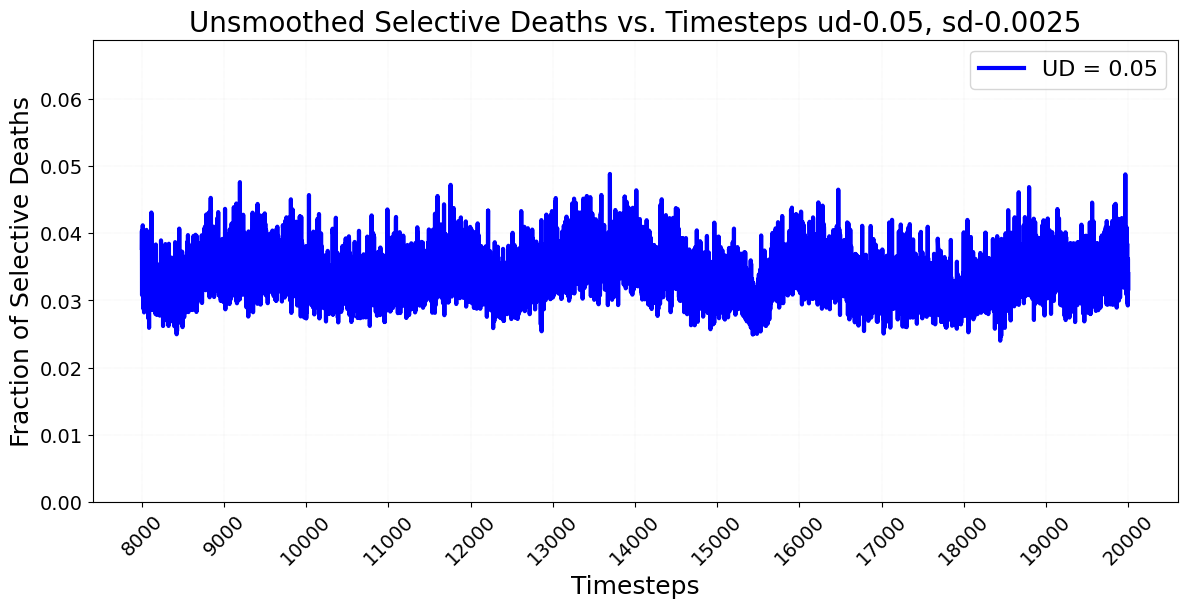

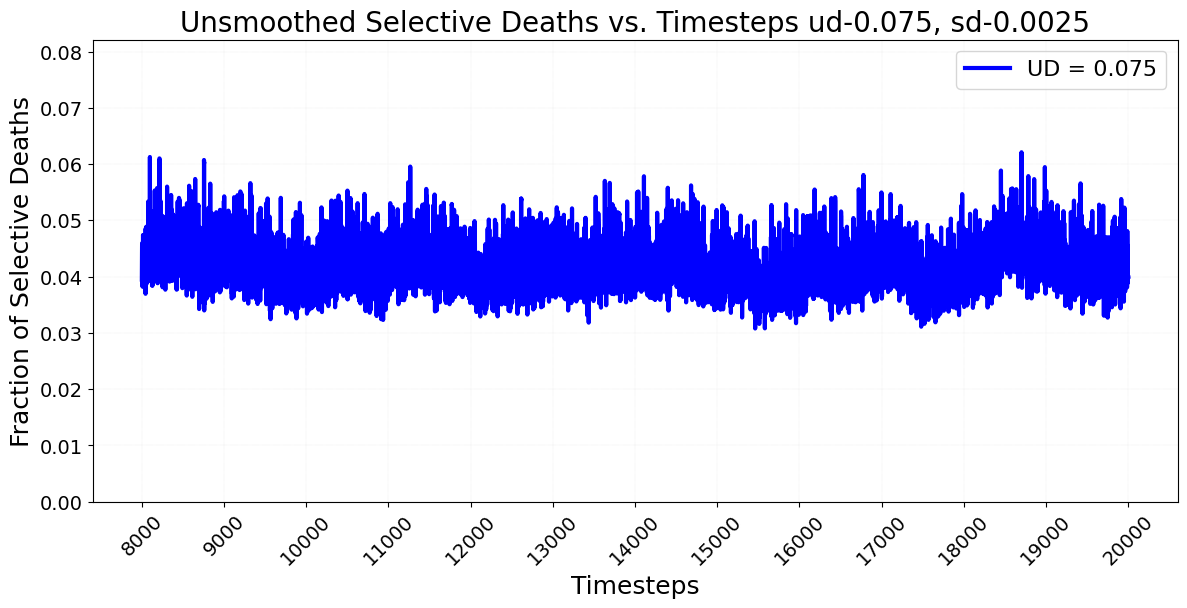

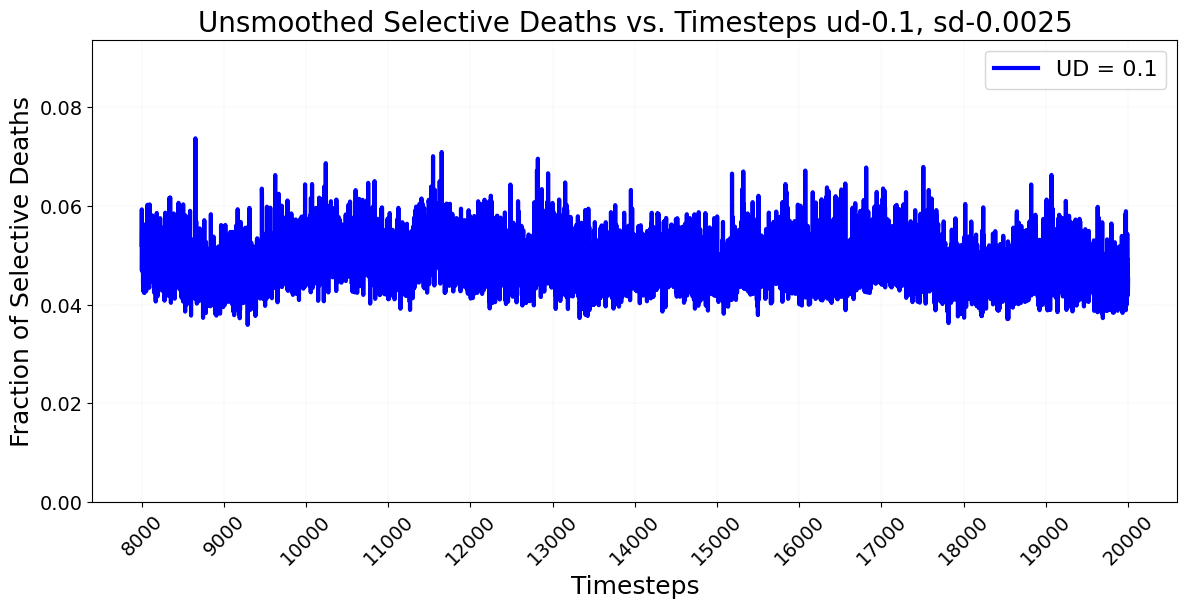

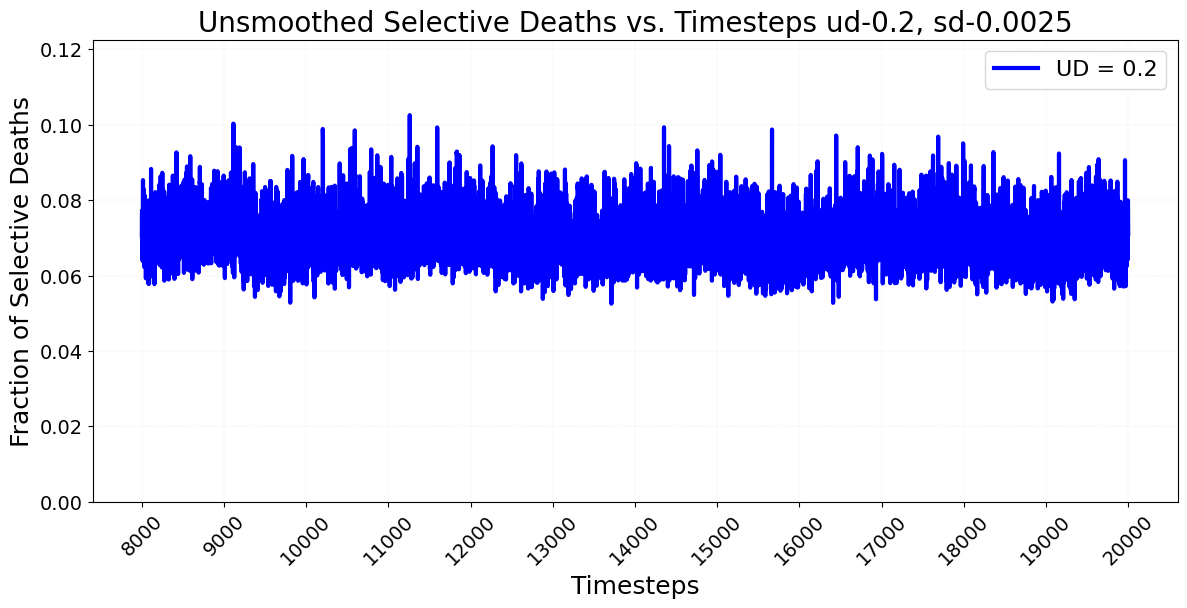

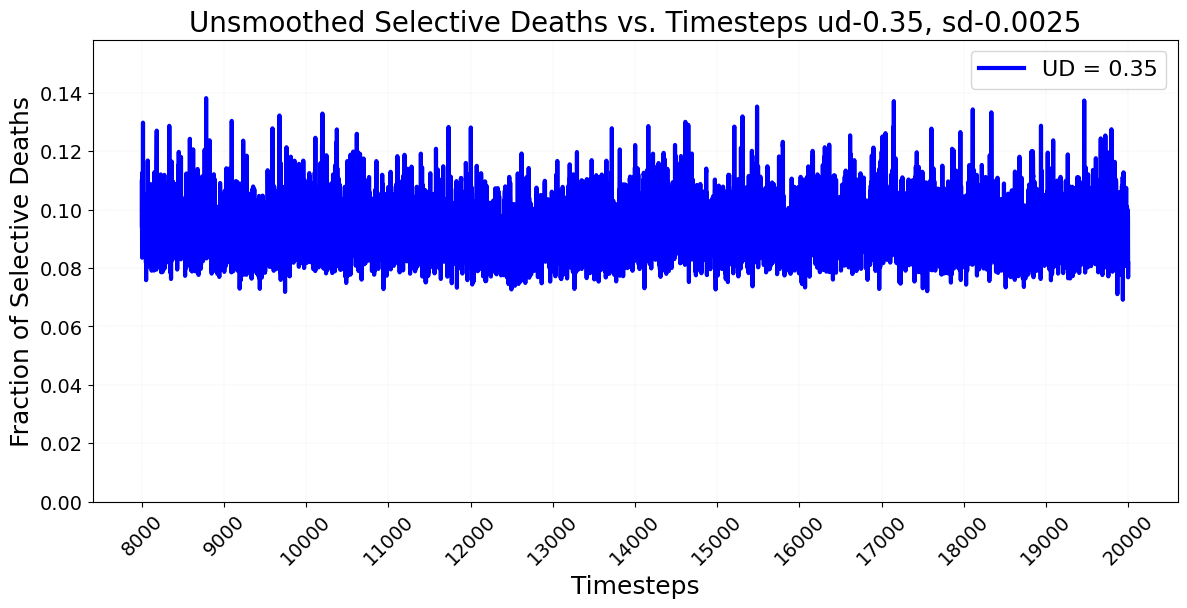

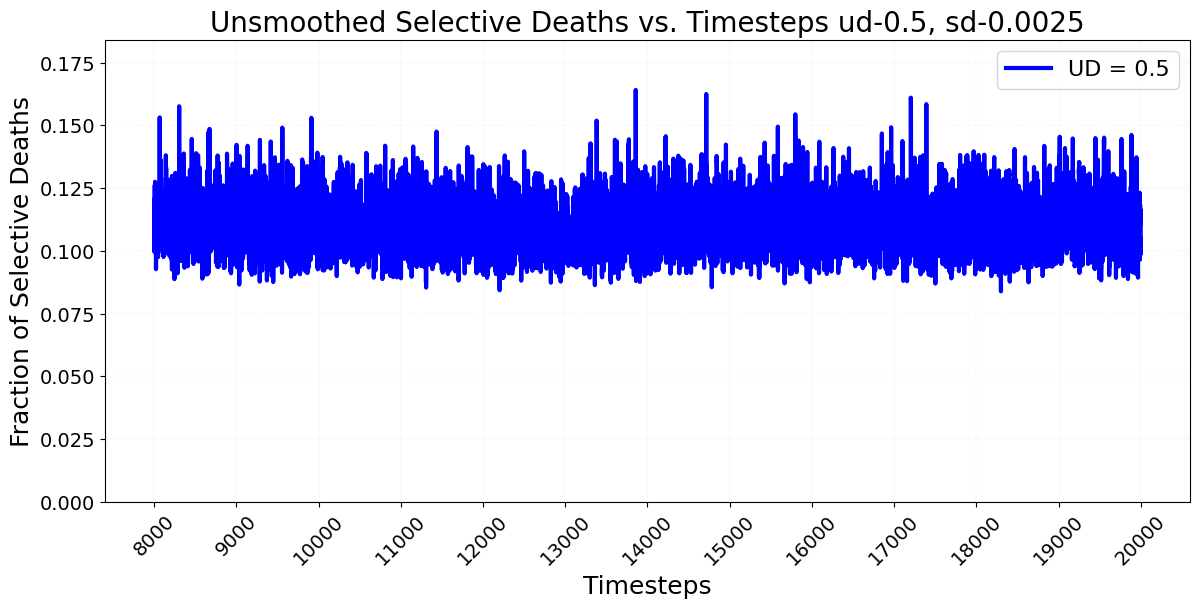

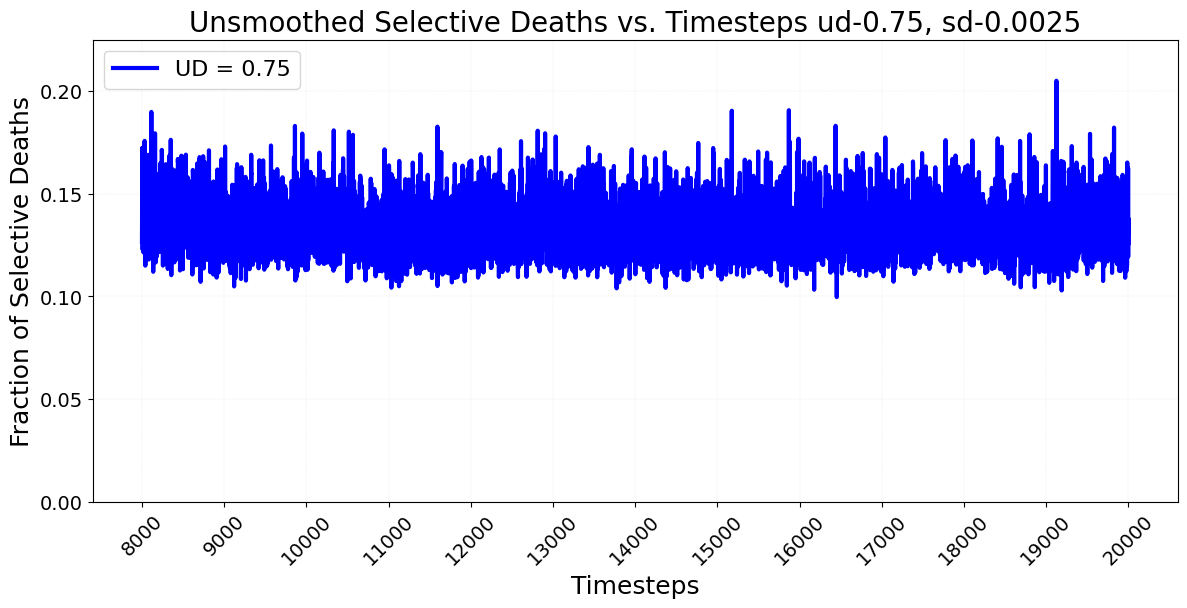

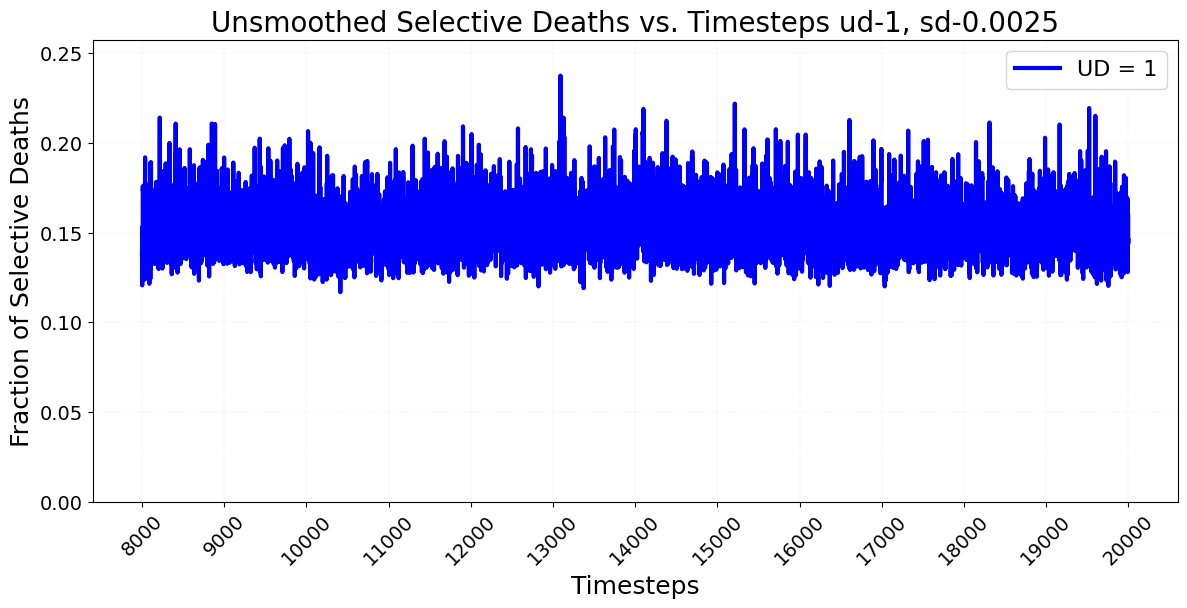

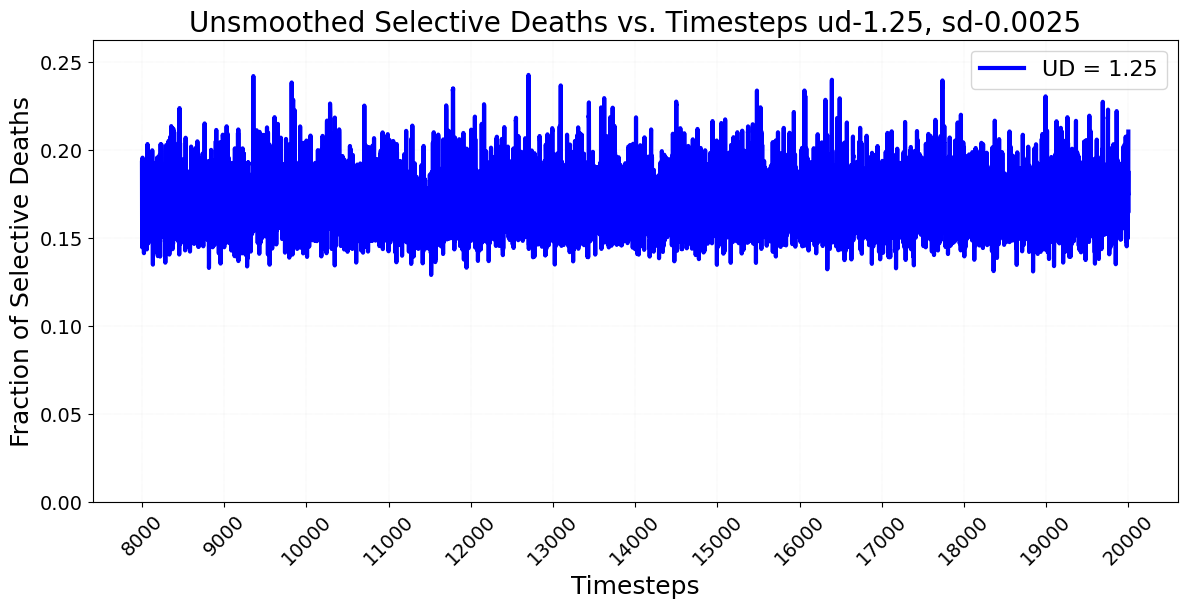

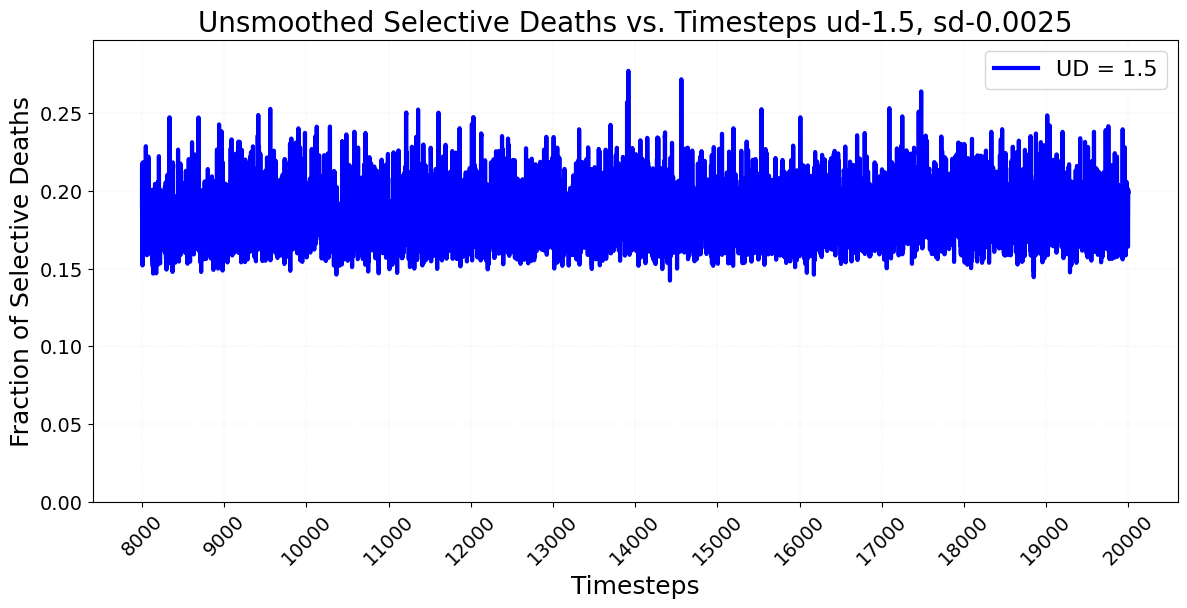

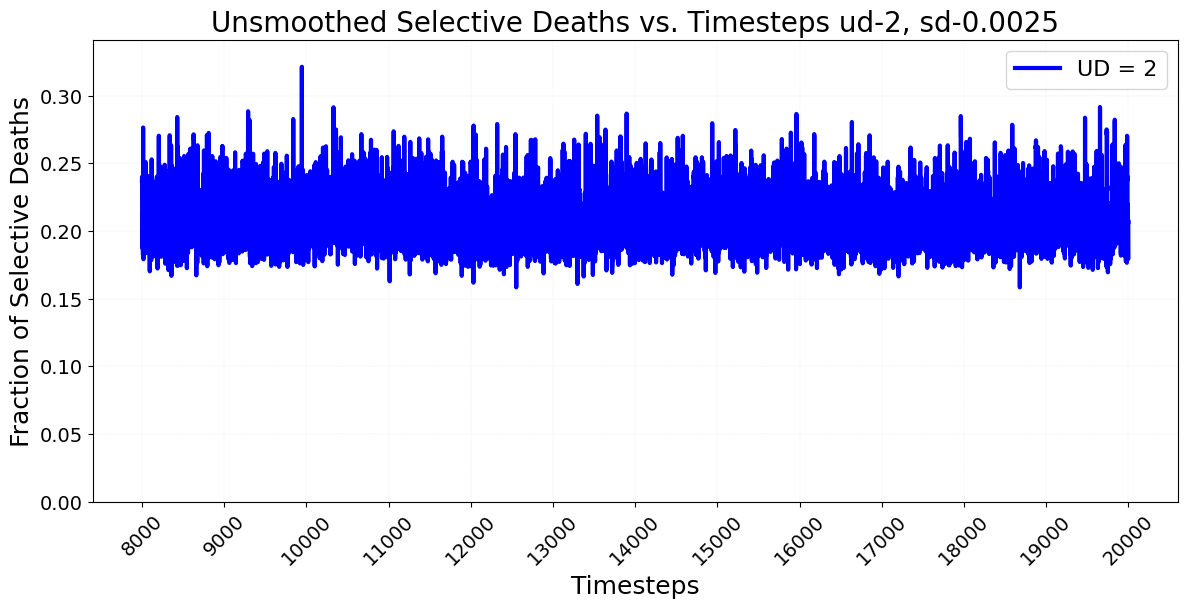

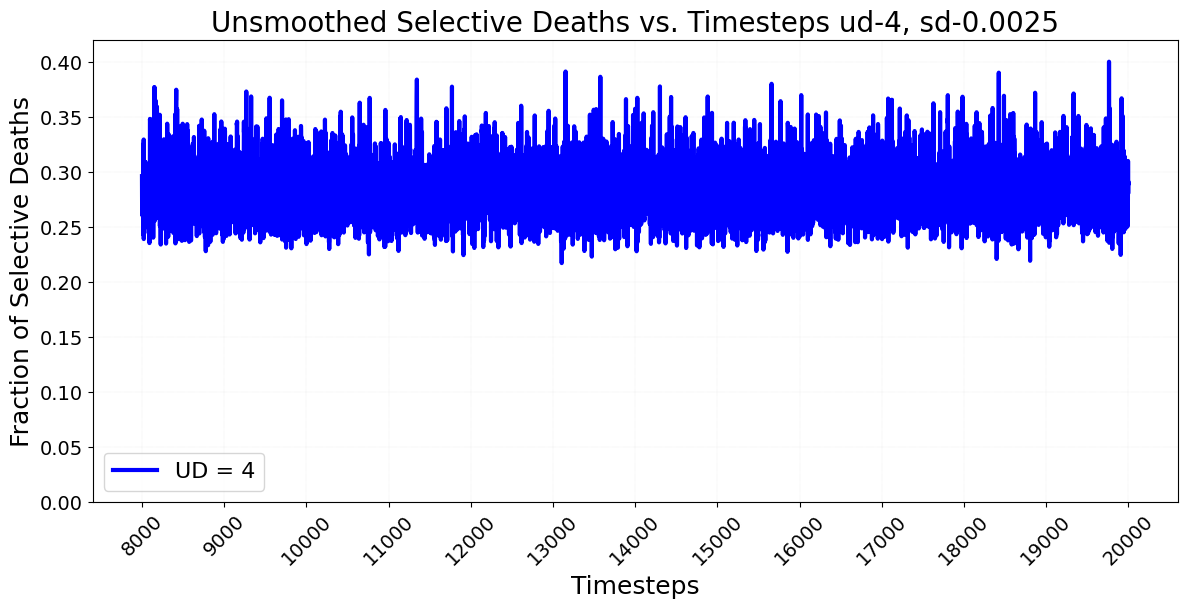

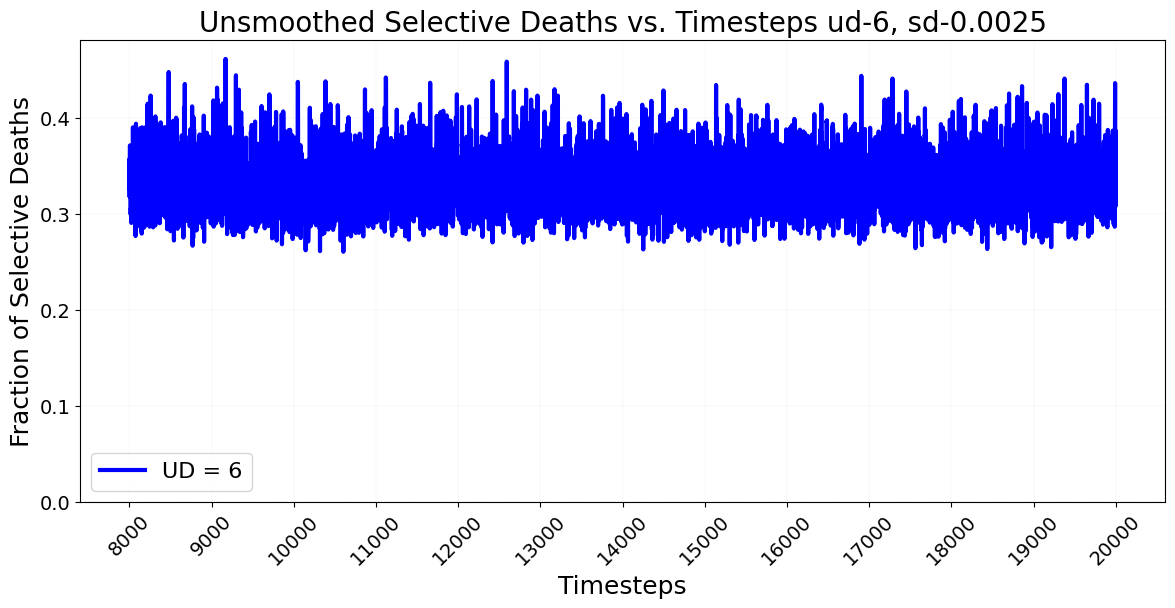

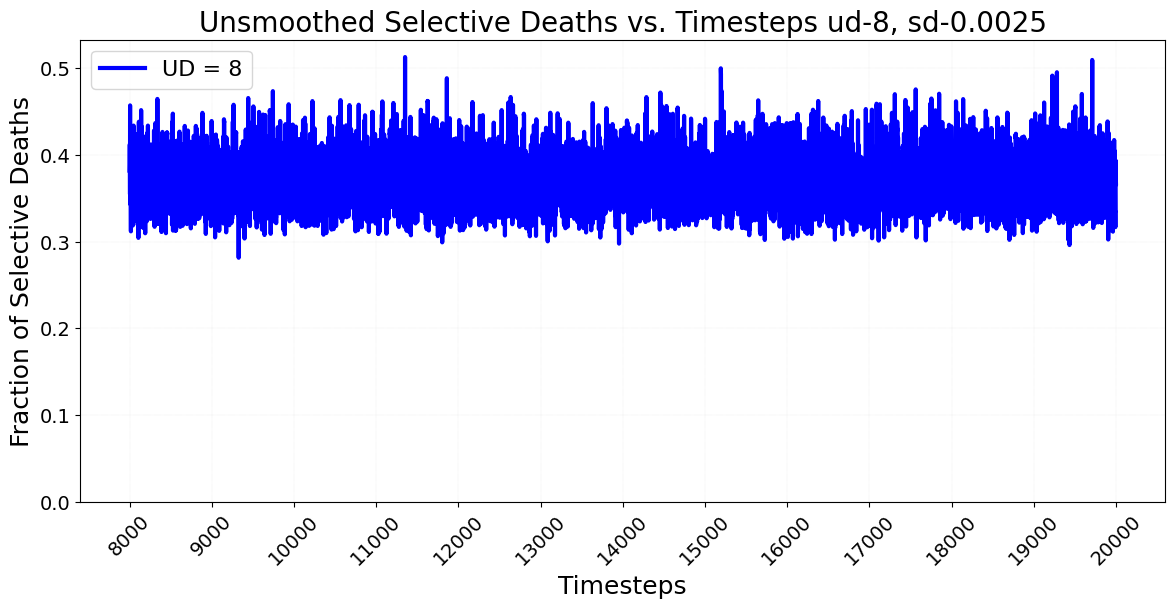

In [7]:
# Timesteps vs. F. Sel. Deaths: No Smoothing, Burnin

start = 8000  # Start X-axis here
end = 20000
tick_interval = 1000  # Adjust tick interval to match smoothed data spacing

sliced_data, sliced_timesteps = parse_data.slice_data(data, timesteps, burnin)

for sd, (ud, dataset) in sliced_data:
    if ud in wanted:
        # Set tick marks based on actual sliced timesteps
        tick_locs = list(range(start, max(sliced_timesteps) + 1, tick_interval))

        # Compute y-limits
        #y_min = 0
        #y_max = 1
        y_min = 0
        y_max = max(dataset) + 0.02

        fig = plt.figure(figsize=(14, 6))
        fig.patch.set_facecolor('white')
        ax = fig.gca()
        ax.set_facecolor('white')

        ax.plot(sliced_timesteps, dataset, label=f"UD = {ud}", color='blue')
        ax.set_xlabel("Timesteps")
        ax.set_ylabel("Fraction of Selective Deaths")
        ax.set_title(f"Unsmoothed Selective Deaths vs. Timesteps ud-{ud}, {sd}")
        ax.grid(True, linestyle=':', color='lightgray', linewidth=0.3)
        ax.set_xticks(tick_locs)
        ax.set_ylim(y_min, y_max)
        plt.xticks(rotation=45)
        ax.legend()

        plt.savefig(f"/Users/cameronliu/Desktop/Research/Selective Death Graphs/No Burnin/{sd[3:]}/unsmoothed_{sd[3:]}_ud-{ud}_vs_timesteps.png", dpi=300, bbox_inches='tight')
        plt.show()
